# CDS6344 Social Media Computing
## Airline Tweet Sentiment Analysis, Opinion Mining and ABSA

Dataset: US Airline Twitter dataset

Main target label: `ground_truth_sentiment`

G10

Group Members:

SHATHIA NAIDU A/L RENGASAMY (1211110571)

HARIKUMAR A/L MALAIRAJU (1211109990)

#Introduction

Social media is one of the main platforms where airline passengers share their travel experiences. Many passengers use Twitter to complain about delays, cancelled flights, baggage issues, booking problems, staff response, seat comfort and food service. These tweets are useful because they show real customer feedback in a short and direct form. However, tweet text is also difficult to analyse because it often contains mentions, hashtags, emojis, short forms, repeated characters and informal language.

This project focuses on airline tweet sentiment analysis, opinion mining and aspect-based sentiment analysis. The aim is not only to classify tweets into positive, neutral and negative sentiment, but also to understand the important service areas discussed by passengers. For this reason, the notebook follows a complete NLP pipeline starting from data loading, preprocessing, rule-based ground truth creation, feature engineering, model training, evaluation, opinion mining and ABSA.

The original dataset contains 14,640 tweets. After checking the data and removing duplicate tweet text, 14,409 unique tweets are used for analysis and modelling. The original airline_sentiment column is not used as the final target label. Instead, a new rule-based ground truth sentiment label is created after preprocessing. This helps make the target construction process more transparent and avoids using lexicon models to create the same labels that they are later compared against.

Several types of models are used in this project. TextBlob, VADER and AFINN are used as lexicon-based baseline models. Logistic Regression and Linear SVM are trained using TF-IDF features and SMOTE. BiLSTM is used as a deep learning model to learn word sequence patterns from tweets. DistilBERT is used as a transformer model because it can understand the contextual meaning of words in tweet text.

#Problem Statement

Airline companies receive a large number of tweets from passengers every day. Manually reading and understanding all these tweets is time-consuming and not practical. A tweet may contain feedback about delay, booking, baggage, customer service, comfort or food. General sentiment classification can show whether a tweet is positive, neutral or negative, but it does not clearly show which airline service aspect is causing the sentiment.

Another problem is the construction of sentiment labels. The dataset already contains an airline_sentiment column, but using it directly would not show the full preprocessing and target creation process. At the same time, using TextBlob, VADER and AFINN to create the final target label would make the evaluation less fair because these lexicon models are also tested later as baseline models. To avoid this issue, the notebook removes the original sentiment label from the modelling process and creates a rule-based ground truth sentiment label only after preprocessing.

The main problem addressed in this project is how to clean, represent, classify and interpret airline tweets using a complete NLP pipeline. The solution must include sentiment classification, feature engineering, model comparison, opinion mining, ABSA, visualisation and insight generation. The final output should not only report model accuracy, but also explain what passengers are mainly discussing and which airline service areas are linked to positive or negative sentiment.

#Objectives

###The objectives of this notebook are:

*   To load and understand the US Airline Twitter dataset before preprocessing.
*   To clean tweet text by handling URLs, mentions, emojis, abbreviations,  punctuation, stopwords and duplicated tweet content.

*   To apply tokenisation, stopword removal, lemmatisation and POS tagging so that the tweet text is suitable for analysis and modelling.
*   To create a rule-based ground truth sentiment label after preprocessing without using the original airline_sentiment column as the modelling target.


*   To apply lexicon-based sentiment analysis using TextBlob, VADER and AFINN as baseline models.
*   To prepare TF-IDF features for traditional machine learning models.


*   To train and evaluate Logistic Regression and Linear SVM using TF-IDF features, SMOTE and cross-validation.
*   To train a BiLSTM deep learning model using padded token sequences.


*   To fine-tune a DistilBERT transformer model for tweet-level sentiment classification.
*   To compare all model categories using accuracy, precision, recall, F1-score, confusion matrix and generalisation gap.


*   To perform opinion mining by extracting important opinion targets and opinion expressions from the tweets.
*   To perform aspect-based sentiment analysis using airline service aspect categories such as delays, baggage, booking, customer service, comfort and food.


*   To generate useful insights from the final results so that the analysis explains both model performance and airline service issues.














# Segment 1: Environment Setup

In [ ]:
!pip install vaderSentiment afinn textblob wordcloud transformers datasets accelerate torch imbalanced-learn gensim spacy contractions -q
!python -m spacy download en_core_web_sm -q
print("Libraries are ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 19.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Libraries are ready.


---
# Segment 2: Data Loading and Dataset Understanding
The dataset is loaded and checked before preprocessing.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
print("Core libraries imported.")

Core libraries imported.


In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Social media computing/Tweets.csv'
df = pd.read_csv(file_path, encoding='utf-8')

if 'airline_sentiment' in df.columns:
    df = df.drop(columns=['airline_sentiment'])

print("Dataset loaded successfully")
print("File path:", file_path)
print("Dataset shape:", df.shape)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully
File path: /content/drive/MyDrive/Social media computing/Tweets.csv
Dataset shape: (14640, 13)


,tweet_id,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,5.703060e+17,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,24/2/2015 11:35,NaN,Eastern Time (US & Canada)
1,5.703010e+17,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,24/2/2015 11:15,NaN,Pacific Time (US & Canada)
2,5.703010e+17,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,24/2/2015 11:15,Lets Play,Central Time (US & Canada)
3,5.703010e+17,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,24/2/2015 11:15,NaN,Pacific Time (US & Canada)
4,5.703010e+17,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,24/2/2015 11:14,NaN,Pacific Time (US & Canada)


In [ ]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   tweet_id                   14640 non-null  float64
 1   negativereason             9178 non-null   object 
 2   negativereason_confidence  10522 non-null  float64
 3   airline                    14640 non-null  object 
 4   airline_sentiment_gold     40 non-null     object 
 5   name                       14640 non-null  object 
 6   negativereason_gold        32 non-null     object 
 7   retweet_count              14640 non-null  int64  
 8   text                       14640 non-null  object 
 9   tweet_coord                1019 non-null   object 
 10  tweet_created              14640 non-null  object 
 11  tweet_location             9907 non-null   object 
 12  user_timezone              9820 non-null   object 
dtypes: float64(2), int64(1), object(

In [ ]:
col_desc = {
    'tweet_id': 'Unique tweet identifier',
    'negativereason': 'Reason category given for negative airline feedback',
    'negativereason_confidence': 'Confidence score for the negative reason',
    'airline': 'Airline mentioned in the tweet',
    'airline_sentiment_gold': 'Sparse gold label column, not used for modelling',
    'name': 'Twitter username',
    'negativereason_gold': 'Sparse gold negative reason column, not used for modelling',
    'retweet_count': 'Number of retweets',
    'text': 'Raw tweet text',
    'tweet_coord': 'GPS coordinates where available',
    'tweet_created': 'Tweet timestamp',
    'tweet_location': 'Self-reported user location',
    'user_timezone': 'User timezone setting',
}

print("Column descriptions:")
for col in df.columns:
    print(f"  {col:35s} -> {col_desc.get(col, 'Additional metadata')}")

label_status = pd.DataFrame({
    'Item': ['Original sentiment column', 'Ground truth sentiment label'],
    'Status': ['Removed before modelling', 'Created after preprocessing using airline rule-based keywords']
})
display(label_status)

Column descriptions:
  tweet_id                            -> Unique tweet identifier
  negativereason                      -> Reason category given for negative airline feedback
  negativereason_confidence           -> Confidence score for the negative reason
  airline                             -> Airline mentioned in the tweet
  airline_sentiment_gold              -> Sparse gold label column, not used for modelling
  name                                -> Twitter username
  negativereason_gold                 -> Sparse gold negative reason column, not used for modelling
  retweet_count                       -> Number of retweets
  text                                -> Raw tweet text
  tweet_coord                         -> GPS coordinates where available
  tweet_created                       -> Tweet timestamp
  tweet_location                      -> Self-reported user location
  user_timezone                       -> User timezone setting


,Item,Status
0,Original sentiment column,Removed before modelling
1,Ground truth sentiment label,Created after preprocessing using airline rule...


In [ ]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Missing Value Analysis:")
print(missing_df[missing_df['Missing Count'] > 0])

# remove rows without tweet text
df = df.dropna(subset=['text']).copy()
print()
print(f"After dropping missing text rows: {len(df):,} rows remain.")

# remove repeated tweet text before preprocessing
duplicate_key = df['text'].astype(str).str.lower().str.strip()
duplicate_count = duplicate_key.duplicated().sum()
df = df.assign(text_duplicate_key=duplicate_key)
df = df.drop_duplicates(subset=['text_duplicate_key']).drop(columns=['text_duplicate_key'])
df = df.reset_index(drop=True)

print(f"Duplicate tweet rows removed: {duplicate_count:,}")
print(f"Final rows after duplicate check: {len(df):,}")


Missing Value Analysis:
                           Missing Count  Missing %
negativereason                      5462      37.31
negativereason_confidence           4118      28.13
airline_sentiment_gold             14600      99.73
negativereason_gold                14608      99.78
tweet_coord                        13621      93.04
tweet_location                      4733      32.33
user_timezone                       4820      32.92

After dropping missing text rows: 14,640 rows remain.
Duplicate tweet rows removed: 231
Final rows after duplicate check: 14,409


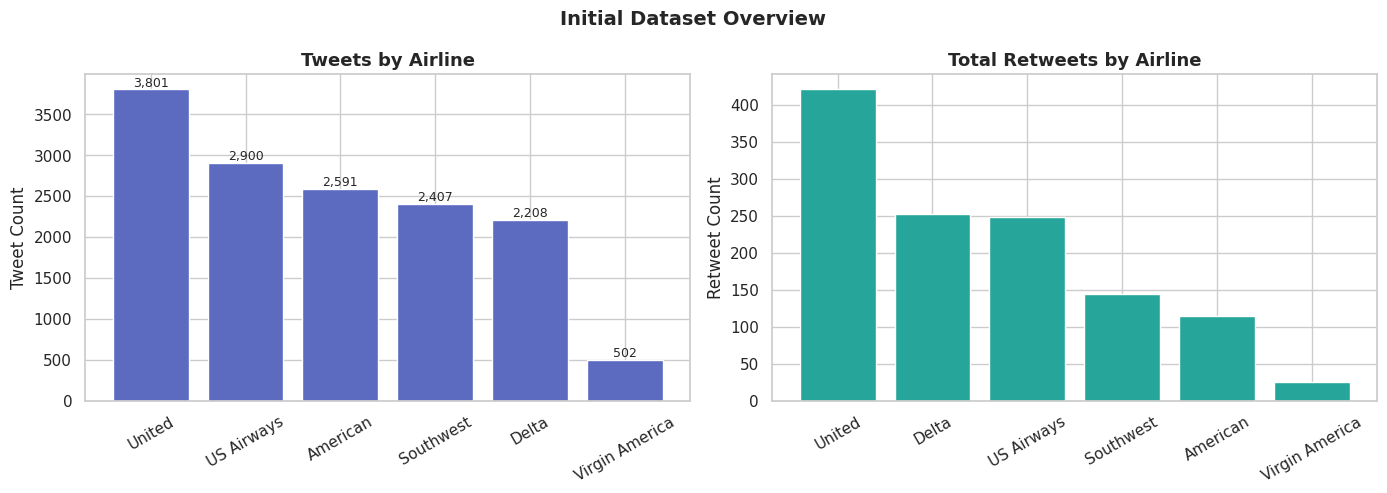

In [ ]:
color_map = {'positive': '#4CAF50', 'neutral': '#9E9E9E', 'negative': '#F44336'}
colors_map = {'Positive': '#4CAF50', 'Neutral': '#9E9E9E', 'Negative': '#F44336'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

airline_counts = df['airline'].value_counts()
axes[0].bar(airline_counts.index, airline_counts.values, color='#5C6BC0', edgecolor='white')
axes[0].set_title('Tweets by Airline', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Tweet Count')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(airline_counts.values):
    axes[0].text(i, v + 40, f'{v:,}', ha='center', fontsize=9)

retweets = df.groupby('airline')['retweet_count'].sum().sort_values(ascending=False)
axes[1].bar(retweets.index, retweets.values, color='#26A69A', edgecolor='white')
axes[1].set_title('Total Retweets by Airline', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Retweet Count')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Initial Dataset Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Tweet count by airline:
airline
United            3801
US Airways        2900
American          2591
Southwest         2407
Delta             2208
Virgin America     502
Name: count, dtype: int64

Location metadata availability:
           Field  Available Count  Available %
  Tweet location             9748        67.65
   User timezone             9667        67.09
Tweet coordinate             1003         6.96


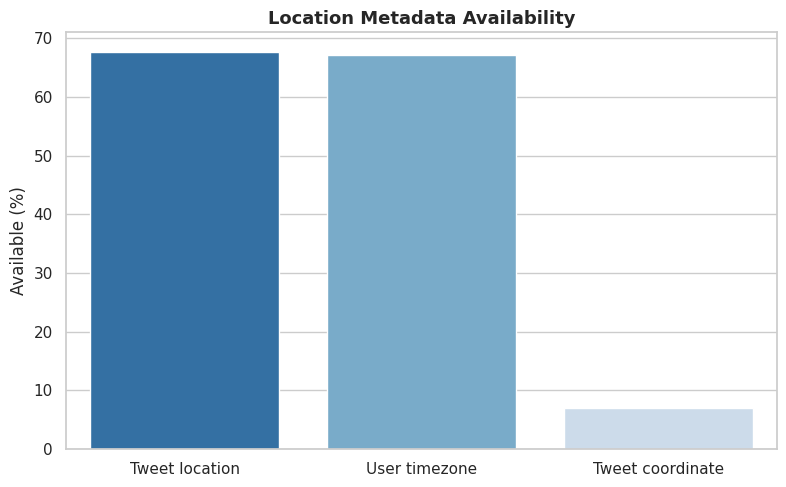

In [ ]:
print("Tweet count by airline:")
print(df['airline'].value_counts())

location_available = df['tweet_location'].notna().sum()
timezone_available = df['user_timezone'].notna().sum()
coord_available = df['tweet_coord'].notna().sum()

meta_df = pd.DataFrame({
    'Field': ['Tweet location', 'User timezone', 'Tweet coordinate'],
    'Available Count': [location_available, timezone_available, coord_available],
})
meta_df['Available %'] = (meta_df['Available Count'] / len(df) * 100).round(2)

print("\nLocation metadata availability:")
print(meta_df.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=meta_df, x='Field', y='Available %', palette='Blues_r')
plt.title('Location Metadata Availability', fontsize=13, fontweight='bold')
plt.ylabel('Available (%)')
plt.xlabel('')
plt.tight_layout()
plt.show()

Tweet length statistics:
count    14409.00
mean       104.27
std         35.85
min         12.00
25%         77.00
50%        115.00
75%        136.00
max        186.00
Name: tweet_length, dtype: float64


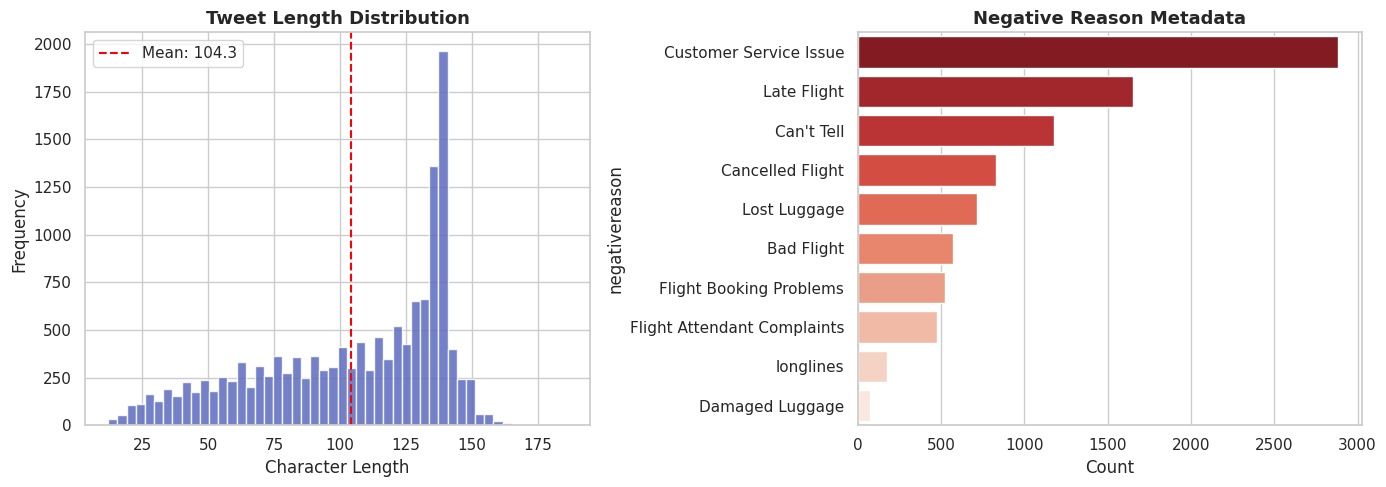

In [ ]:
df['tweet_length'] = df['text'].astype(str).apply(len)
print("Tweet length statistics:")
print(df['tweet_length'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['tweet_length'], bins=50, color='#5C6BC0', edgecolor='white', alpha=0.85)
axes[0].axvline(df['tweet_length'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['tweet_length'].mean():.1f}")
axes[0].set_title('Tweet Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].legend()

neg_reasons = df['negativereason'].dropna().value_counts().head(10)
sns.barplot(x=neg_reasons.values, y=neg_reasons.index, palette='Reds_r', ax=axes[1])
axes[1].set_title('Negative Reason Metadata', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

---
# Segment 3: Text Preprocessing
Raw tweet text is cleaned using normalization, tokenization, stopword removal and lemmatization.

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus   import stopwords, wordnet
from nltk.stem     import WordNetLemmatizer
from nltk          import pos_tag

for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4',
            'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng']:
    nltk.download(pkg, quiet=True)

print("NLTK resources loaded successfully.")

NLTK resources loaded successfully.


In [ ]:
abbreviation_dict = {
    'u': 'you', 'ur': 'your', 'r': 'are', 'pls': 'please',
    'plz': 'please', 'msg': 'message', 'thx': 'thanks',
    'gr8': 'great', 'omg': 'oh my god', 'lol': 'laughing out loud',
    'tbh': 'to be honest', 'imo': 'in my opinion',
    'asap': 'as soon as possible', 'fyi': 'for your information',
    'brb': 'be right back', 'dm': '', 'rt': '', 'cc': '',
    'b4': 'before', 'nvm': 'nevermind', 'ty': 'thank you', 'w8': 'wait',
}

emoji_sentiment_map = {
    '\u2764\ufe0f': ' love positive ',
    '\u2764': ' love positive ',
    '\U0001f60d': ' love positive ',
    '\U0001f970': ' love positive ',
    '\U0001f60a': ' happy positive ',
    '\U0001f600': ' happy positive ',
    '\U0001f603': ' happy positive ',
    '\U0001f604': ' happy positive ',
    '\U0001f601': ' happy positive ',
    '\U0001f642': ' happy positive ',
    '\U0001f44d': ' good positive ',
    '\U0001f64f': ' thanks positive ',
    '\U0001f44f': ' good positive ',
    '\U0001f622': ' sad negative ',
    '\U0001f62d': ' sad negative ',
    '\U0001f621': ' angry negative ',
    '\U0001f620': ' angry negative ',
    '\U0001f44e': ' bad negative ',
    '\U0001f624': ' angry negative ',
    '\U0001f612': ' unhappy negative ',
    '\U0001f61e': ' disappointed negative ',
    '\U0001f614': ' disappointed negative ',
    '\U0001f620': ' angry negative ',
}

def replace_emoji_sentiment(text):
    text = str(text)
    for symbol, replacement in emoji_sentiment_map.items():
        text = text.replace(symbol, replacement)
    return text

df['text_for_sentiment'] = df['text'].apply(replace_emoji_sentiment)

try:
    import contractions
    HAS_CONTRACTIONS = True
except ImportError:
    HAS_CONTRACTIONS = False
    print("contractions library not found - skipping expansion.")

print(f"Abbreviation dictionary: {len(abbreviation_dict)} entries loaded.")
print("Emoji sentiment conversion is ready.")

Abbreviation dictionary: 22 entries loaded.
Emoji sentiment conversion is ready.


In [ ]:
def tokenize_tweet(text):
    if pd.isna(text) or str(text).strip() == '':
        return []
    text = str(text)
    if HAS_CONTRACTIONS:
        try:
            text = contractions.fix(text)
        except Exception:
            pass
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'&\w+;', '', text)
    words = [abbreviation_dict.get(w, w) for w in text.split()]
    return word_tokenize(' '.join(words), preserve_line=True)

df['tokens'] = df['text_for_sentiment'].apply(tokenize_tweet)
print("Tokenisation complete.")
df[['text', 'text_for_sentiment', 'tokens']].head(3)

Tokenisation complete.


,text,text_for_sentiment,tokens
0,@VirginAmerica What @dhepburn said.,@VirginAmerica What @dhepburn said.,"[what, said, .]"
1,@VirginAmerica plus you've added commercials t...,@VirginAmerica plus you've added commercials t...,"[plus, you, have, added, commercials, to, the,..."
2,@VirginAmerica I didn't today... Must mean I n...,@VirginAmerica I didn't today... Must mean I n...,"[i, did, not, today, ..., must, mean, i, need,..."


In [ ]:
# remove common stopwords but keep negation words
stop_words = set(stopwords.words('english'))
for word in ['not', 'no', 'nor']:
    stop_words.discard(word)

custom_stops = {
    'amp', 'via', 'co', 'http', 'https', 'com', 'www',
    'twitter', 'tweet', 'rt', 'dm', 'cc',
    'flight', 'flights', 'airline', 'airlines', 'airways',
    'united', 'american', 'southwest', 'delta', 'virgin', 'jetblue',
    'usairways', 'americanair', 'southwestair', 'virginamerica',
    'plane', 'planes', 'airport', 'air', 'aa',
    'im', 'ive', 'id', 'youre', 'theyre', 'weve', 'ill', 'll', 've',
    'get', 'got', 'go', 'going', 'make', 'take', 'thing', 'things',
    'someone', 'anything', 'still', 'even', 'yet', 'already',
    'today', 'tomorrow', 'yesterday', 'another',
    'jfk', 'dfw', 'lax', 'phl', 'bos', 'ewr', 'sfo', 'lga', 'ord',
    'iad', 'dca', 'clt', 'atl', 'phx', 'sea', 'las', 'mco', 'pdx',
    'nyc', 'bna'
}
stop_words.update(custom_stops)

for word in ['not', 'no', 'nor']:
    stop_words.discard(word)

negation_tokens = {
    "n't", 'nt', 'n’t', 'not', 'no', 'nor', 'cannot', 'cant', 'wont',
    'dont', 'didnt', 'doesnt', 'isnt', 'wasnt', 'arent', 'couldnt',
    'wouldnt', 'shouldnt', 'never'
}


def clean_tokens(tokens):
    cleaned = []
    for raw_word in tokens:
        raw_word = str(raw_word).lower().strip()
        word = re.sub(r'[^a-zA-Z0-9_]', '', raw_word)

        # keep negation as one useful word
        if raw_word in negation_tokens or word in negation_tokens:
            word = 'not'

        if len(word) > 1 and word not in stop_words and not word.isdigit():
            cleaned.append(word)
    return cleaned


df['cleaned_tokens'] = df['tokens'].apply(clean_tokens)
print("Stopword removal and token cleaning complete.")
df[['tokens', 'cleaned_tokens']].head(3)

Stopword removal and token cleaning complete.


,tokens,cleaned_tokens
0,"[what, said, .]",[said]
1,"[plus, you, have, added, commercials, to, the,...","[plus, added, commercials, experience, tacky]"
2,"[i, did, not, today, ..., must, mean, i, need,...","[not, must, mean, need, trip]"


In [ ]:
lemmatizer = WordNetLemmatizer()
protected = {'us', 'was', 'has', 'not', 'no', 'nor'}

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    if tag.startswith('V'):
        return wordnet.VERB
    if tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN

def lemmatize_tokens(tokens):
    if not tokens:
        return []
    tagged = pos_tag(tokens)
    return [
        w if w in protected else lemmatizer.lemmatize(w, pos=get_wordnet_pos(t))
        for w, t in tagged
    ]

df['lemmatized'] = df['cleaned_tokens'].apply(lemmatize_tokens)
print("Lemmatisation complete.")
df[['cleaned_tokens', 'lemmatized']].head(3)

Lemmatisation complete.


,cleaned_tokens,lemmatized
0,[said],[say]
1,"[plus, added, commercials, experience, tacky]","[plus, added, commercial, experience, tacky]"
2,"[not, must, mean, need, trip]","[not, must, mean, need, trip]"


In [ ]:
df['pos_tags'] = df['lemmatized'].apply(lambda t: pos_tag(t) if t else [])
df['nouns'] = df['pos_tags'].apply(lambda p: [w for w, t in p if t.startswith('NN')])
df['adjectives'] = df['pos_tags'].apply(lambda p: [w for w, t in p if t.startswith('JJ')])

df['joined_tokenized_text'] = df['lemmatized'].apply(lambda t: ' '.join(t))
df['final_processed_text'] = df['joined_tokenized_text']
df['clean_text'] = df['joined_tokenized_text']

print("POS tagging and text preparation complete.")
df[['text', 'text_for_sentiment', 'clean_text']].head(5)

POS tagging and text preparation complete.


,text,text_for_sentiment,clean_text
0,@VirginAmerica What @dhepburn said.,@VirginAmerica What @dhepburn said.,say
1,@VirginAmerica plus you've added commercials t...,@VirginAmerica plus you've added commercials t...,plus added commercial experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,@VirginAmerica I didn't today... Must mean I n...,not must mean need trip
3,@VirginAmerica it's really aggressive to blast...,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,@VirginAmerica and it's a really big bad thing...,really big bad


In [ ]:
from wordcloud import WordCloud, STOPWORDS
import re

# filter extra noisy words only for word cloud display
wordcloud_stopwords = set(STOPWORDS)
wordcloud_stopwords.update({
    'nt', 'dont', 'cant', 'wont', 'didnt', 'doesnt', 'isnt', 'wasnt',
    'flight', 'flights', 'airline', 'airlines',
    'united', 'american', 'southwest', 'delta', 'virgin',
    'usairways', 'usairway', 'jetblue', 'americanair',
    'southwestair', 'virginamerica', 'unitedairlines',
    'aa', 'dm', 'rt', 've', 'll', 'don', 'didn', 'doesn',
    'not', 'no', 'nor', 'amp', 'http', 'https', 'www', 'com', 'co',
    'tweet', 'twitter', 'via', 'get', 'got', 'go', 'please', 'pls',
    'positive', 'negative', 'neutral',
    'guy', 'say', 'said', 'one', 'two', 'make', 'take', 'still',
    'know', 'look', 'see', 'let', 'use', 'come', 'back',
    'able', 'even', 'yet', 'ago', 'min', 'mins', 'minute', 'minutes',
    'rep', 'pas', 'flt', 'flightled', 'flightr', 'fleek', 'senger',
    'rebooked', 'rebook', 'booked', 'already', 'someone', 'anything', 'thing',
    'jfk', 'dfw', 'lax', 'phl', 'bos', 'ewr', 'sfo', 'lga', 'ord', 'iad',
    'dca', 'clt', 'atl', 'phx', 'sea', 'las', 'mco', 'pdx', 'nyc', 'bna',
    'boston', 'chicago', 'dallas', 'denver', 'vegas', 'miami', 'houston',
    'fleet', 'airport', 'air', 'plane', 'destination', 'dragon',
    'destinationdragon', 'welllate', 'receiveshow', 'terribleridiculous',
    'delayeddisappointed', 'response', 'respond', 'show', 'name',
    'send', 'tell', 'give', 'check', 'find', 'sure', 'think', 'want',
    'need', 'really', 'much', 'well', 'keep', 'leave', 'first', 'last',
    'next', 'year', 'week', 'home', 'tonight', 'morning', 'night',
    'right', 'due', 'account', 'available', 'open', 'website', 'system',
    'customer', 'service', 'help', 'phone', 'email', 'call', 'time',
    'work', 'book', 'change', 'seat', 'ticket', 'trip', 'travel',
    'agent', 'crew', 'staff', 'people', 'passenger', 'class', 'weather',
    'newark', 'alway', 'always', 'though', 'instead', 'nothing',
    'tarmac', 'flightlation', 'flightlated', 'flightled', 'flighted',
    'dissappointed', 'dissapointed', 'dissapointment', 'disappointment',
    'frustrated', 'frustrating', 'frustration', 'birththday',
    'company', 'business', 'mile', 'miles', 'credit', 'voucher', 'disappointed'
})

wordcloud_normalize_map = {
    'amaze': 'amazing', 'amazed': 'amazing', 'amazing': 'amazing',
    'appreciated': 'appreciate', 'appreciating': 'appreciate',
    'thanks': 'thank', 'thankful': 'thank', 'thx': 'thank',
    'loved': 'love', 'lovely': 'love',
    'helped': 'helpful', 'helping': 'helpful',
    'enjoyed': 'enjoy', 'enjoying': 'enjoy',
    'delayed': 'delay', 'delays': 'delay',
    'cancelled': 'cancel', 'canceled': 'cancel', 'cancellation': 'cancel',
    'waiting': 'wait', 'waited': 'wait',
    'holding': 'hold',
    'baggage': 'bag', 'bags': 'bag', 'luggage': 'bag',
    'issues': 'issue', 'problems': 'problem',
    'disappoint': 'disappointed', 'disappointing': 'disappointed',
    'dissapointed': 'disappointed', 'dissappointed': 'disappointed',
    'frustrate': 'frustrated', 'frustrating': 'frustrated',
    'failed': 'fail', 'failure': 'fail',
    'answered': 'answer', 'answering': 'answer'
}

sentiment_wordcloud_stopwords = {
    'Positive': {
        'sad', 'bad', 'delay', 'cancel', 'hold', 'wait', 'miss', 'problem',
        'issue', 'refund', 'late', 'fail', 'bag', 'lose', 'lost'
    },
    'Neutral': {
        'sad', 'bad', 'delay', 'delayed', 'cancel', 'cancelled', 'hold',
        'wait', 'miss', 'problem', 'issue', 'refund', 'late', 'fail',
        'good', 'great', 'love', 'thank', 'thanks', 'best', 'awesome',
        'amazing', 'happy', 'appreciate'
    },
    'Negative': {
        'good', 'great', 'love', 'thank', 'thanks', 'best', 'awesome',
        'amazing', 'happy', 'appreciate', 'nice', 'excellent',
        'frustrated', 'disappointed', 'dissapointed', 'dissappointed', 'disappointed'
    }
}

airport_code_pattern = re.compile(r'^[a-z]{3}$')
allowed_short_words = {'bad', 'sad', 'mad', 'wow', 'pay', 'bag'}
joined_noise_patterns = (
    'destinationdragon', 'welllate', 'receiveshow', 'terribleridiculous',
    'delayeddisappointed', 'flightled', 'flightr', 'dragon', 'destination',
    'flightlation', 'flightlated', 'dissappointed', 'dissapointed', 'disappointed'
)


def clean_wordcloud_word(word):
    word = re.sub(r'[^a-z]', '', str(word).lower().strip())
    if not word:
        return ''
    return wordcloud_normalize_map.get(word, word)


def get_wordcloud_text(subset, sentiment=None):
    words = []
    extra_stops = sentiment_wordcloud_stopwords.get(sentiment, set())

    for tokens in subset['lemmatized']:
        for token in tokens:
            word = clean_wordcloud_word(token)
            if not word:
                continue
            if not re.fullmatch(r'[a-z]{3,}', word):
                continue
            if word in wordcloud_stopwords or word in extra_stops:
                continue
            if any(noise in word for noise in joined_noise_patterns):
                continue
            if len(word) > 15:
                continue
            if airport_code_pattern.fullmatch(word) and word not in allowed_short_words:
                continue
            if len(word) <= 3 and word not in allowed_short_words:
                continue
            words.append(word)
    return ' '.join(words)

print("Word cloud text filter is ready.")


Word cloud text filter is ready.


---
# Segment 4: Exploratory Data Analysis (After Preprocessing)
This segment checks frequent terms, word clouds, POS patterns and TF-IDF keywords.

Total filtered tokens: 63,736

Top 20 Most Frequent Words After Preprocessing:
   Word  Frequency
  thank       1828
    bag       1250
   hour       1140
 cancel       1034
  delay        979
   wait        742
   hold        706
   gate        536
   good        426
   late        422
    bad        397
   miss        381
   love        368
  great        342
   lose        308
problem        306
  board        299
  issue        287
    pay        277
 number        257


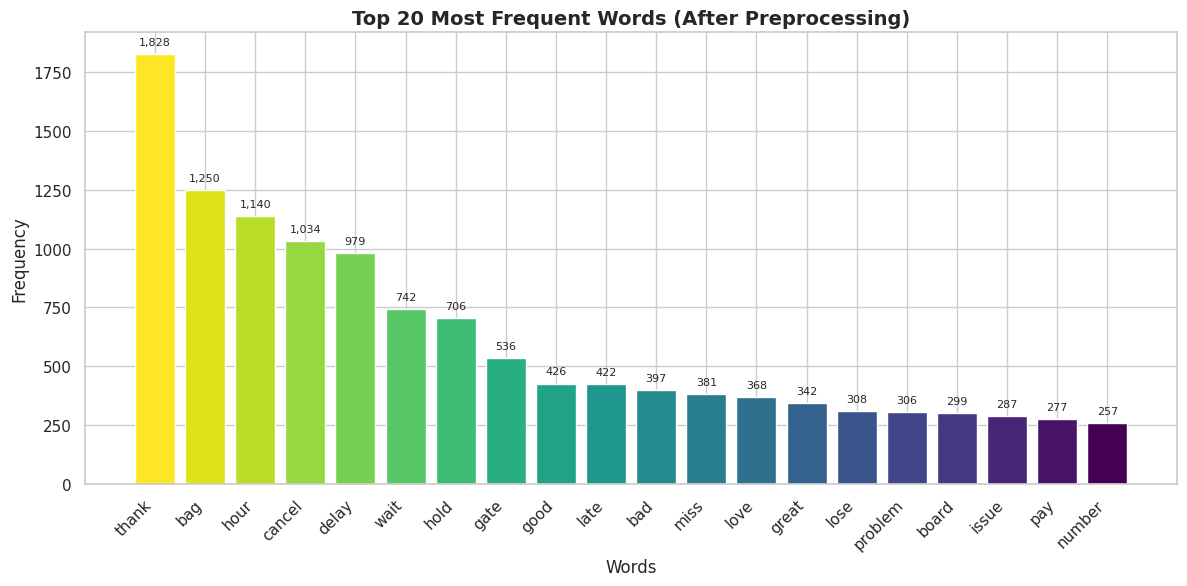

In [ ]:
all_words    = get_wordcloud_text(df).split()
word_freq    = Counter(all_words)
common_words = word_freq.most_common(20)
freq_df      = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

print(f"Total filtered tokens: {len(all_words):,}")
print("\nTop 20 Most Frequent Words After Preprocessing:")
print(freq_df.to_string(index=False))

plt.figure(figsize=(12, 6))
colors = plt.cm.viridis_r(np.linspace(0, 1, 20))
bars   = plt.bar(freq_df['Word'], freq_df['Frequency'], color=colors, edgecolor='white')
plt.title('Top 20 Most Frequent Words (After Preprocessing)', fontsize=14, fontweight='bold')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, freq_df['Frequency']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

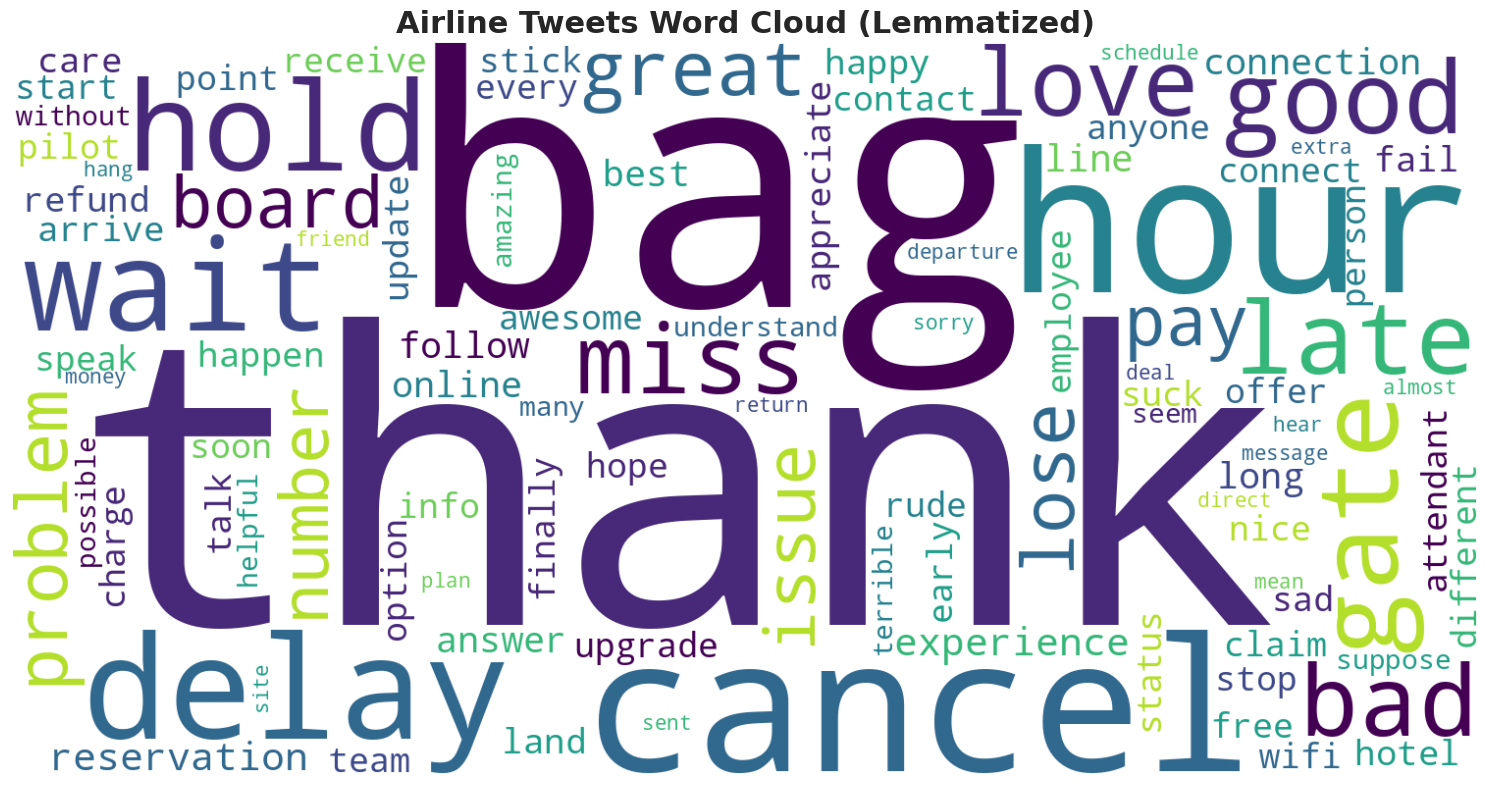

In [ ]:
wordcloud_text = get_wordcloud_text(df)

wordcloud_palette = [
    '#440154', '#482878', '#3E4989', '#31688E',
    '#26828E', '#1F9E89', '#35B779', '#6DCD59', '#B4DE2C'
]


def make_color_func(palette):
    def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
        if random_state is None:
            return palette[0]
        return palette[random_state.randint(0, len(palette) - 1)]
    return color_func

wc = WordCloud(
    width=1500,
    height=750,
    background_color='white',
    stopwords=wordcloud_stopwords,
    max_words=100,
    collocations=False,
    prefer_horizontal=0.95,
    min_font_size=9,
    relative_scaling=0.45,
    margin=5,
    random_state=42
).generate(wordcloud_text)

wc = wc.recolor(color_func=make_color_func(wordcloud_palette), random_state=42)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Airline Tweets Word Cloud (Lemmatized)', fontsize=22, fontweight='bold')
plt.tight_layout()
plt.show()


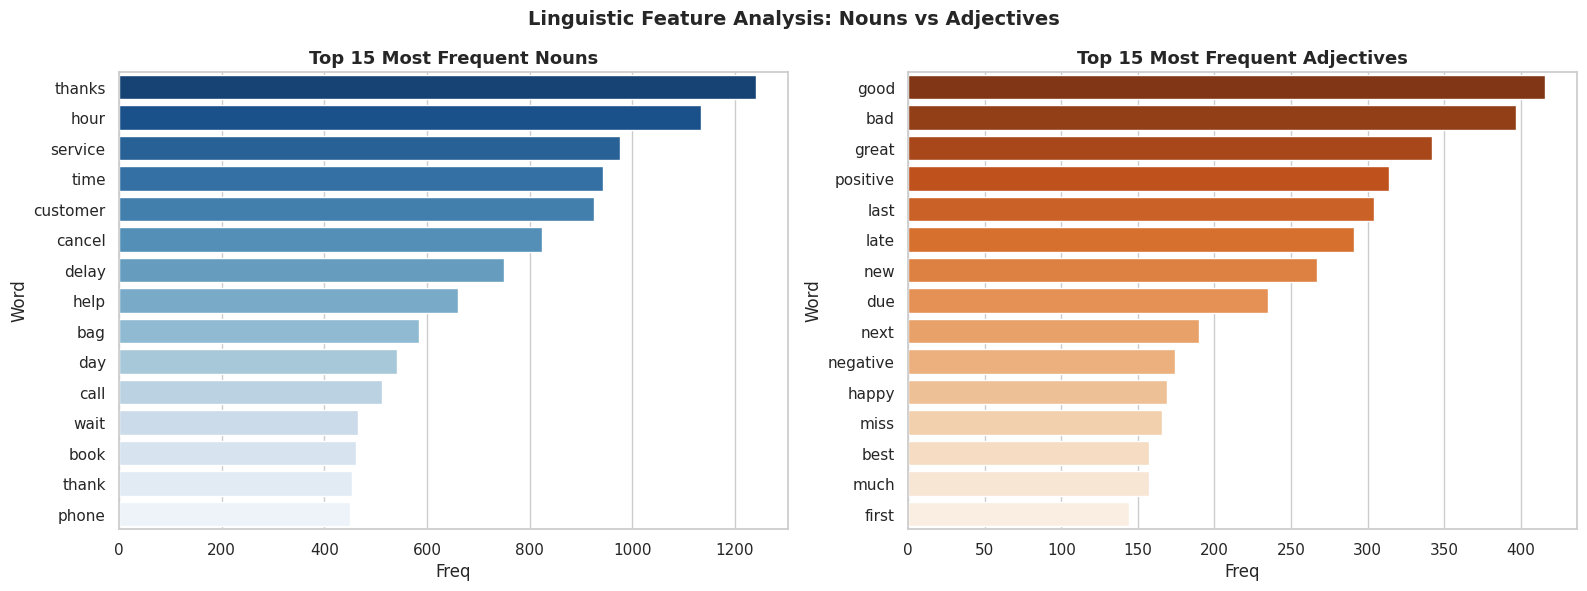

Unique nouns:      7,127
Unique adjectives: 3,385


In [ ]:
all_nouns = [w for n in df['nouns']      for w in n]
all_adjs  = [w for a in df['adjectives'] for w in a]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

noun_df = pd.DataFrame(Counter(all_nouns).most_common(15), columns=['Word', 'Freq'])
adj_df  = pd.DataFrame(Counter(all_adjs).most_common(15),  columns=['Word', 'Freq'])

sns.barplot(data=noun_df, x='Freq', y='Word', palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 15 Most Frequent Nouns', fontsize=13, fontweight='bold')

sns.barplot(data=adj_df, x='Freq', y='Word', palette='Oranges_r', ax=axes[1])
axes[1].set_title('Top 15 Most Frequent Adjectives', fontsize=13, fontweight='bold')

plt.suptitle('Linguistic Feature Analysis: Nouns vs Adjectives',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Unique nouns:      {len(set(all_nouns)):,}")
print(f"Unique adjectives: {len(set(all_adjs)):,}")

Full TF-IDF matrix shape: (14409, 9862)
TF-IDF preview using top 20 terms:


,not,help,cancel,service,delay,customer,hold,wait,fly,bag,us,one,try,flightled,back,gate,phone,guy,change,seat
0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.1972,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


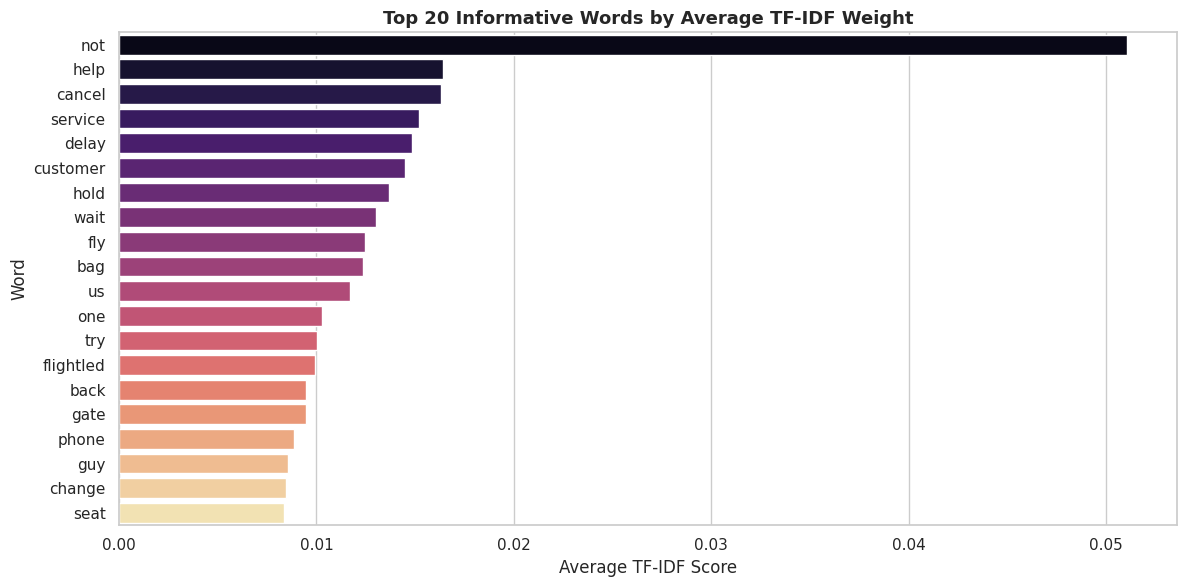

Higher TF-IDF score = more useful term in this corpus.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF is shown for feature engineering and EDA
joined_texts = df['joined_tokenized_text'].fillna('').astype(str)

tfidf_noise_words = set(stop_words)
tfidf_noise_words.update({
    'nt', 'notnot', 'dont', 'cant', 'wont', 'didnt', 'doesnt', 'isnt', 'wasnt',
    'thank', 'thanks', 'please', 'pls', 'hi', 'hello', 'hey',
    'hour', 'hours', 'time', 'day', 'night', 'morning',
    'today', 'tomorrow', 'yesterday', 'need', 'want', 'would', 'could', 'should',
    'helped', 'helping', 'say', 'said', 'tell', 'told', 'call', 'called',
    'jfk', 'dfw', 'lax', 'phl', 'bos', 'ewr', 'sfo', 'lga', 'ord', 'iad',
    'dca', 'clt', 'atl', 'phx', 'sea', 'las', 'mco', 'pdx', 'nyc', 'bna'
})
for word in ['not', 'no', 'nor']:
    tfidf_noise_words.discard(word)

tfidf_eda = TfidfVectorizer(
    max_features=10000,
    stop_words=list(tfidf_noise_words),
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b',
    ngram_range=(1, 1)
)

tfidf_matrix_eda = tfidf_eda.fit_transform(joined_texts)
feature_names = tfidf_eda.get_feature_names_out()

avg_tfidf = tfidf_matrix_eda.mean(axis=0).A1
tfidf_scores = pd.Series(avg_tfidf, index=feature_names).sort_values(ascending=False)
top_tfidf = tfidf_scores.head(20)

top_terms = top_tfidf.index.tolist()
top_indices = [list(feature_names).index(term) for term in top_terms]
tfidf_preview_df = pd.DataFrame(
    tfidf_matrix_eda[:5, top_indices].toarray(),
    columns=top_terms
)

print(f"Full TF-IDF matrix shape: {tfidf_matrix_eda.shape}")
print("TF-IDF preview using top 20 terms:")
display(tfidf_preview_df.round(4))

plt.figure(figsize=(12, 6))
sns.barplot(x=top_tfidf.values, y=top_tfidf.index, palette='magma')
plt.title('Top 20 Informative Words by Average TF-IDF Weight', fontsize=13, fontweight='bold')
plt.xlabel('Average TF-IDF Score')
plt.ylabel('Word')
plt.tight_layout()
plt.show()
print("Higher TF-IDF score = more useful term in this corpus.")

---
# Segment 5: Rule-Based Ground Truth and Lexicon Analysis

The original sentiment column is not used. After preprocessing, a rule-based airline sentiment label is created from the cleaned tweet text. TextBlob, VADER, and AFINN are applied after that as lexicon baseline models.

In [ ]:
# create ground truth after preprocessing
# airline keyword rules are used like the tutorial lab

positive_keywords = {
    'thank', 'thanks', 'thx', 'appreciate', 'appreciated',
    'great', 'good', 'excellent', 'awesome', 'amazing',
    'love', 'loved', 'lovely', 'helpful', 'helped',
    'resolved', 'quick', 'smooth', 'best', 'happy',
    'wonderful', 'perfect', 'nice', 'kudos', 'friendly',
    'impressed', 'enjoy', 'enjoyed', 'easy', 'favorite',
    'fantastic', 'fab', 'cool', 'safe', 'better'
}

negative_keywords = {
    'delay', 'delayed', 'delays', 'late', 'cancel', 'cancelled',
    'canceled', 'cancellation', 'missed', 'miss', 'missing',
    'stuck', 'stranded', 'waiting', 'wait', 'hold', 'holding',
    'hours', 'hour', 'lost', 'baggage', 'bag', 'bags',
    'luggage', 'broken', 'damaged', 'rude', 'worst',
    'awful', 'terrible', 'bad', 'poor', 'horrible',
    'hate', 'disappointed', 'disappointing', 'frustrated',
    'frustrating', 'angry', 'upset', 'suck', 'sucks',
    'fail', 'failed', 'failure', 'issue', 'issues',
    'problem', 'problems', 'refund', 'compensation',
    'unacceptable', 'ridiculous', 'useless', 'nightmare',
    'complaint', 'complain', 'error', 'wrong', 'denied',
    'obnoxious', 'tacky', 'aggressive'
}

positive_phrases = [
    'thank you', 'thanks for', 'great service', 'good service',
    'very helpful', 'love flying', 'best airline', 'nice flight',
    'smooth flight', 'on time', 'appreciate your help',
    'you rock', 'well done', 'good job', 'great job'
]

negative_phrases = [
    'not happy', 'not good', 'not helpful', 'no help',
    'no response', 'no answer', 'no one', 'never again',
    'never fly', 'customer service sucks', 'worst airline',
    'worst customer', 'late flight', 'flight delayed',
    'delayed flight', 'lost bag', 'lost baggage',
    'cancelled flight', 'canceled flight', 'missed connection',
    'on hold', 'still waiting', 'need refund', 'want refund',
    'bad service', 'poor service', 'terrible service',
    'rude agent', 'rude staff'
]

neutral_keywords = {
    'gate', 'terminal', 'boarding', 'board', 'schedule',
    'status', 'depart', 'departure', 'arrive', 'arrival',
    'landed', 'ticket', 'reservation', 'itinerary',
    'airport', 'route', 'question', 'info', 'information'
}


def rule_based_ground_truth(clean_text):
    text = str(clean_text).lower()
    words = set(text.split())

    positive_score = sum(1 for word in words if word in positive_keywords)
    negative_score = sum(1 for word in words if word in negative_keywords)

    positive_score += sum(2 for phrase in positive_phrases if phrase in text)
    negative_score += sum(2 for phrase in negative_phrases if phrase in text)

    if 'not' in words and any(w in words for w in ['good', 'happy', 'helpful', 'great', 'resolved']):
        negative_score += 2

    if negative_score > positive_score:
        return 'Negative'
    elif positive_score > negative_score:
        return 'Positive'
    else:
        return 'Neutral'


def rule_source(clean_text, label):
    text = str(clean_text).lower()
    words = set(text.split())

    if label == 'Negative':
        matched = sorted([w for w in words if w in negative_keywords])
        phrase_match = [p for p in negative_phrases if p in text]
        reason = matched[:3] + phrase_match[:1]
        return 'negative rule: ' + ', '.join(reason) if reason else 'negative rule'

    if label == 'Positive':
        matched = sorted([w for w in words if w in positive_keywords])
        phrase_match = [p for p in positive_phrases if p in text]
        reason = matched[:3] + phrase_match[:1]
        return 'positive rule: ' + ', '.join(reason) if reason else 'positive rule'

    matched = sorted([w for w in words if w in neutral_keywords])
    return 'neutral fallback' if not matched else 'neutral rule: ' + ', '.join(matched[:3])


df['ground_truth_sentiment'] = df['clean_text'].fillna('').apply(rule_based_ground_truth)
df['ground_truth_rule_source'] = df.apply(
    lambda row: rule_source(row['clean_text'], row['ground_truth_sentiment']),
    axis=1
)

# use this label for all training and evaluation cells
df['label'] = df['ground_truth_sentiment']

sent_order = ['Positive', 'Neutral', 'Negative']
colors_map = {'Positive': '#4CAF50', 'Neutral': '#9E9E9E', 'Negative': '#F44336'}

gt_counts = df['ground_truth_sentiment'].value_counts().reindex(sent_order).fillna(0).astype(int)

print('Ground truth sentiment distribution:')
print(gt_counts)
print('\nGround truth creation complete.')

Ground truth sentiment distribution:
ground_truth_sentiment
Positive    2303
Neutral     6472
Negative    5634
Name: count, dtype: int64

Ground truth creation complete.


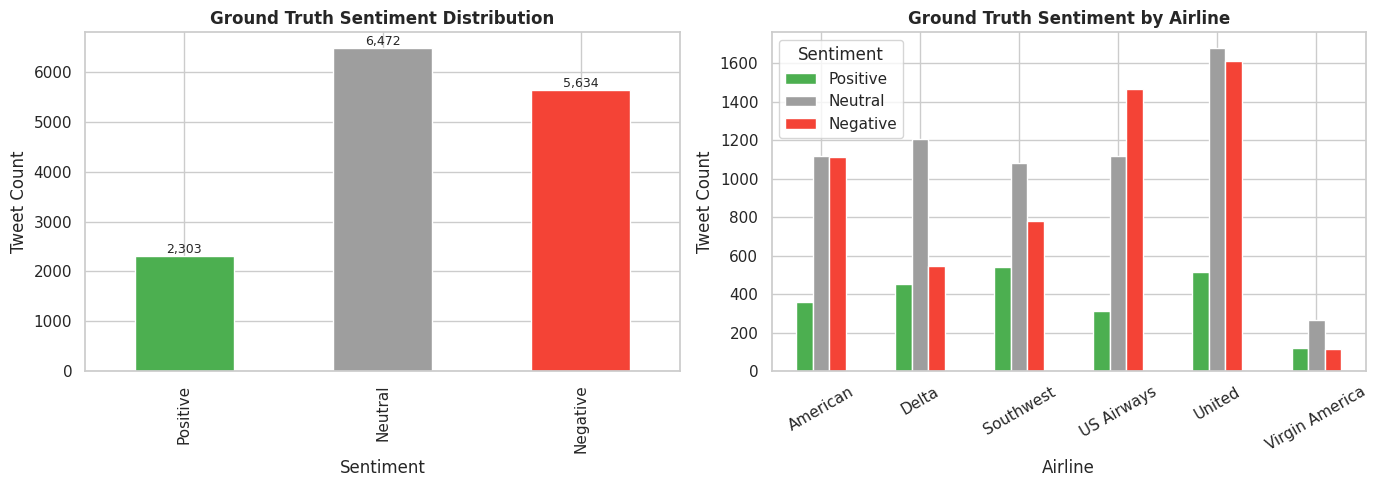

Ground truth preview:


,text,clean_text,ground_truth_sentiment,ground_truth_rule_source
0,@VirginAmerica What @dhepburn said.,say,Neutral,neutral fallback
1,@VirginAmerica plus you've added commercials t...,plus added commercial experience tacky,Negative,negative rule: tacky
2,@VirginAmerica I didn't today... Must mean I n...,not must mean need trip,Neutral,neutral fallback
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...,Negative,"negative rule: aggressive, obnoxious"
4,@VirginAmerica and it's a really big bad thing...,really big bad,Negative,negative rule: bad
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay seat not play really bad f...,Negative,negative rule: bad
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time fly vx ear worm not away,Neutral,neutral fallback
7,@VirginAmerica Really missed a prime opportuni...,really missed prime opportunity men without ha...,Negative,negative rule: missed
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",well notbut,Neutral,neutral fallback
9,"@VirginAmerica it was amazing, and arrived an ...",amaze arrive hour early good,Neutral,neutral rule: arrive


Ground truth sentiment label summary:


,Count,Percentage
ground_truth_sentiment,,
Neutral,6472,44.92
Negative,5634,39.10
Positive,2303,15.98


Exported to: /content/drive/MyDrive/Social media computing/ground_truth_sentiment_labels.csv


In [ ]:
# Show the ground truth labels after preprocessing

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gt_counts.plot(
    kind='bar',
    ax=axes[0],
    color=[colors_map[s] for s in gt_counts.index],
    edgecolor='white'
)
axes[0].set_title('Ground Truth Sentiment Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Tweet Count')
for i, v in enumerate(gt_counts.values):
    axes[0].text(i, v + 60, f'{v:,}', ha='center', fontsize=9)

by_airline = df.groupby(['airline', 'ground_truth_sentiment']).size().unstack(fill_value=0)
by_airline = by_airline.reindex(columns=sent_order, fill_value=0)
by_airline.plot(
    kind='bar',
    ax=axes[1],
    color=[colors_map[s] for s in sent_order],
    edgecolor='white'
)
axes[1].set_title('Ground Truth Sentiment by Airline', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Airline')
axes[1].set_ylabel('Tweet Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.show()

display_cols = ['text', 'clean_text', 'ground_truth_sentiment', 'ground_truth_rule_source']
print('Ground truth preview:')
display(df[display_cols].head(30))

label_summary = pd.DataFrame({
    'Count': df['ground_truth_sentiment'].value_counts(),
    'Percentage': (df['ground_truth_sentiment'].value_counts(normalize=True) * 100).round(2)
})
print('Ground truth sentiment label summary:')
display(label_summary)

export_cols = ['text', 'clean_text', 'ground_truth_sentiment', 'ground_truth_rule_source']
drive_export_path = '/content/drive/MyDrive/Social media computing/ground_truth_sentiment_labels.csv'
local_export_path = 'ground_truth_sentiment_labels.csv'

try:
    df[export_cols].to_csv(drive_export_path, index=False)
    print(f'Exported to: {drive_export_path}')
except Exception:
    df[export_cols].to_csv(local_export_path, index=False)
    print(f'Exported to: {local_export_path}')

In [ ]:
from textblob import TextBlob

# TextBlob is used as a lexicon baseline after ground truth is ready

def textblob_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

def classify_polarity(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['textblob_score'] = df['clean_text'].astype(str).apply(textblob_polarity)
df['textblob_sentiment'] = df['textblob_score'].apply(classify_polarity)

# Keep these names for later cells
df['textblob_raw_sentiment'] = df['textblob_sentiment']
df['textblob_raw_score'] = df['textblob_score']
df['textblob_clean_score'] = df['textblob_score']
df['textblob_clean_sentiment'] = df['textblob_sentiment']

print('TextBlob sentiment scoring complete.')
print(df[['clean_text', 'textblob_score', 'textblob_sentiment']].head(10).to_string())

TextBlob sentiment scoring complete.
                                                                   clean_text  textblob_score textblob_sentiment
0                                                                         say        0.000000            Neutral
1                                      plus added commercial experience tacky        0.000000            Neutral
2                                                     not must mean need trip       -0.312500           Negative
3  really aggressive blast obnoxious entertainment guest face little recourse        0.006250           Positive
4                                                              really big bad       -0.350000           Negative
5                         seriously would pay seat not play really bad fly va       -0.077778           Negative
6                              yes nearly every time fly vx ear worm not away        0.450000           Positive
7                      really missed prime opportunity men 

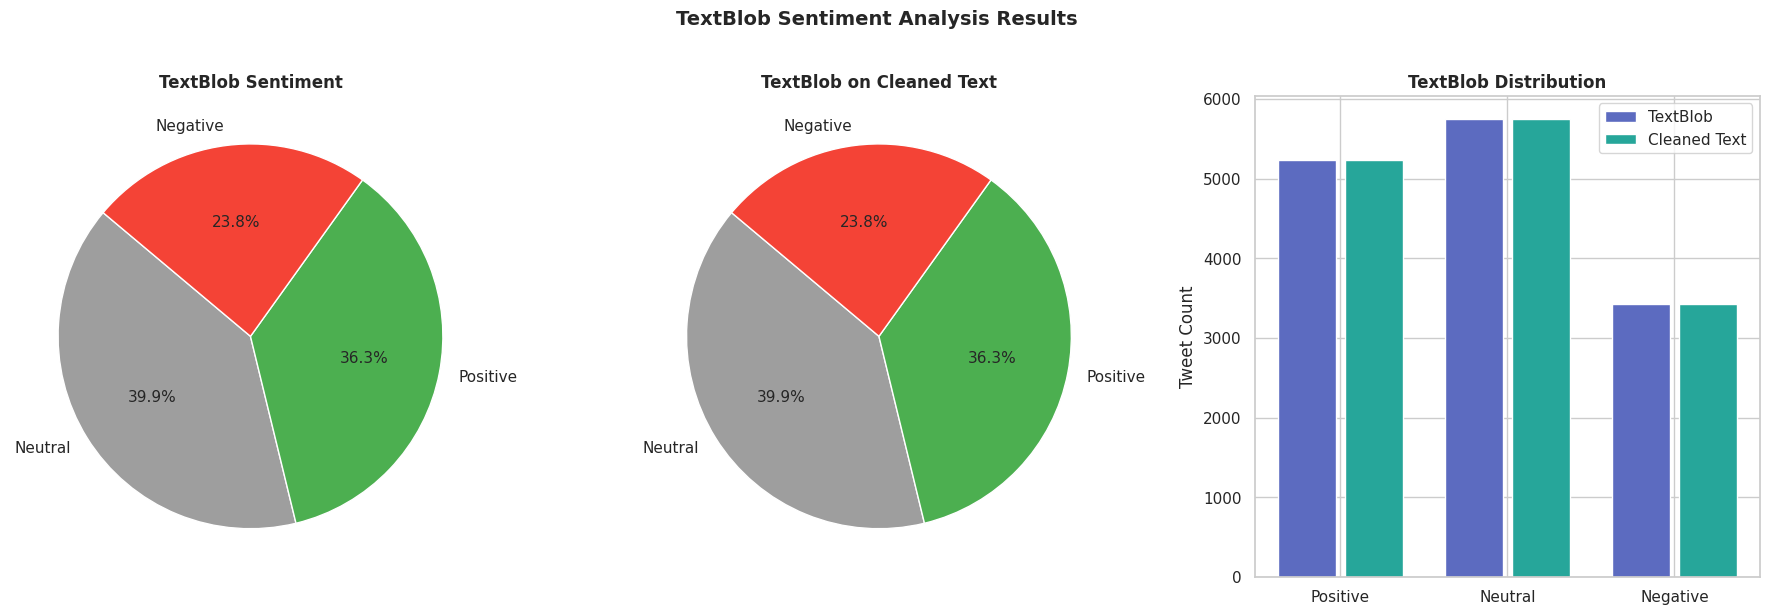

In [ ]:
# Visualise TextBlob results

sent_order = ['Positive', 'Neutral', 'Negative']
raw_counts = df['textblob_raw_sentiment'].value_counts()
cln_counts = df['textblob_clean_sentiment'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].pie(
    raw_counts.values,
    labels=raw_counts.index,
    autopct='%1.1f%%',
    colors=[colors_map.get(l, '#888') for l in raw_counts.index],
    startangle=140
)
axes[0].set_title('TextBlob Sentiment', fontsize=12, fontweight='bold')

axes[1].pie(
    cln_counts.values,
    labels=cln_counts.index,
    autopct='%1.1f%%',
    colors=[colors_map.get(l, '#888') for l in cln_counts.index],
    startangle=140
)
axes[1].set_title('TextBlob on Cleaned Text', fontsize=12, fontweight='bold')

x = np.arange(3)
raw_vals = [raw_counts.get(s, 0) for s in sent_order]
cln_vals = [cln_counts.get(s, 0) for s in sent_order]

axes[2].bar(x - 0.2, raw_vals, 0.35, label='TextBlob', color='#5C6BC0')
axes[2].bar(x + 0.2, cln_vals, 0.35, label='Cleaned Text', color='#26A69A')
axes[2].set_xticks(x)
axes[2].set_xticklabels(sent_order)
axes[2].set_title('TextBlob Distribution', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Tweet Count')
axes[2].legend()

plt.suptitle('TextBlob Sentiment Analysis Results', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# VADER is used as a lexicon baseline after ground truth is ready

analyzer = SentimentIntensityAnalyzer()

def vader_compound(text):
    return analyzer.polarity_scores(str(text))['compound']

def vader_label(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['vader_polarity'] = df['clean_text'].apply(vader_compound)
df['vader_sentiment'] = df['vader_polarity'].apply(vader_label)

vader_counts = df['vader_sentiment'].value_counts()
print('VADER sentiment counts:')
print(vader_counts)
print(df[['clean_text', 'vader_polarity', 'vader_sentiment']].head(10).to_string())

VADER sentiment counts:
vader_sentiment
Positive    6106
Negative    4764
Neutral     3539
Name: count, dtype: int64
                                                                   clean_text  vader_polarity vader_sentiment
0                                                                         say          0.0000         Neutral
1                                      plus added commercial experience tacky          0.0000         Neutral
2                                                     not must mean need trip          0.0000         Neutral
3  really aggressive blast obnoxious entertainment guest face little recourse         -0.3306        Negative
4                                                              really big bad         -0.5829        Negative
5                         seriously would pay seat not play really bad fly va         -0.0179         Neutral
6                              yes nearly every time fly vx ear worm not away          0.4019        Positive
7  

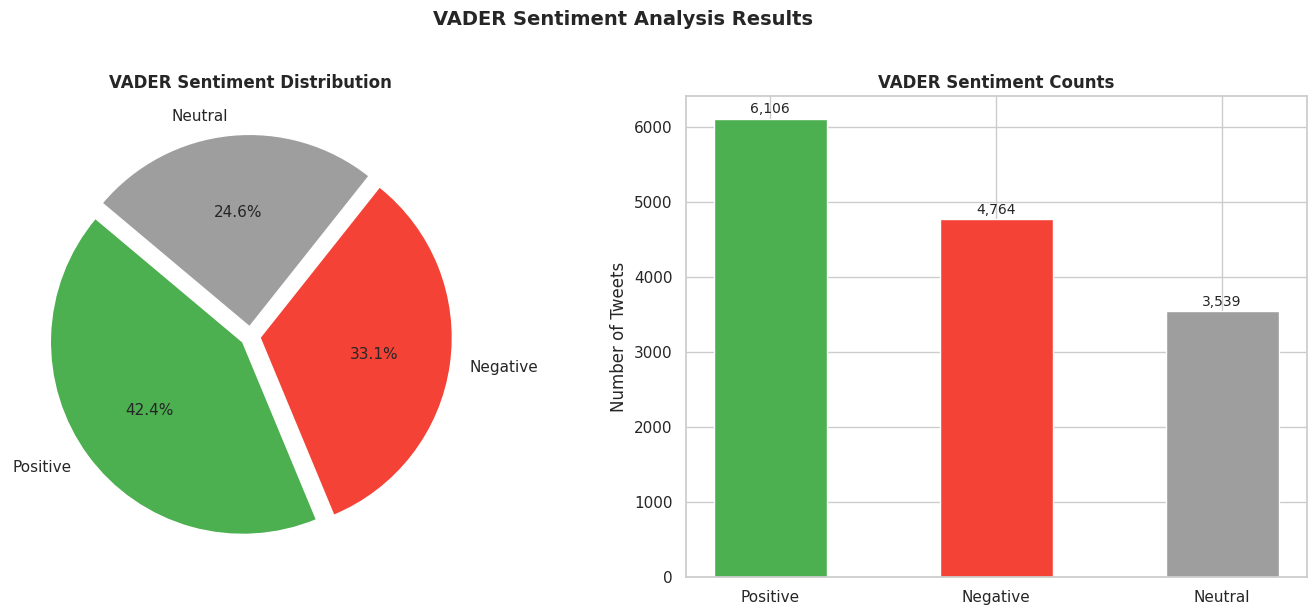

In [ ]:
# Visualise VADER results

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
labels_v = vader_counts.index.tolist()
values_v = vader_counts.values.tolist()

axes[0].pie(
    values_v,
    labels=labels_v,
    autopct='%1.1f%%',
    colors=[colors_map.get(l, '#888') for l in labels_v],
    startangle=140,
    explode=[0.05] * len(labels_v)
)
axes[0].set_title('VADER Sentiment Distribution', fontsize=12, fontweight='bold')

axes[1].bar(
    labels_v,
    values_v,
    color=[colors_map.get(l, '#888') for l in labels_v],
    edgecolor='white',
    width=0.5
)
axes[1].set_title('VADER Sentiment Counts', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Tweets')

for i, (l, v) in enumerate(zip(labels_v, values_v)):
    axes[1].text(i, v + 80, f'{v:,}', ha='center', fontsize=10)

plt.suptitle('VADER Sentiment Analysis Results', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from afinn import Afinn

# AFINN is used as another lexicon baseline

afinn_scorer = Afinn()

df['afinn_score'] = df['clean_text'].apply(afinn_scorer.score)
df['afinn_sentiment'] = df['afinn_score'].apply(
    lambda s: 'Positive' if s > 0 else ('Negative' if s < 0 else 'Neutral')
)

afinn_counts = df['afinn_sentiment'].value_counts()
print('AFINN sentiment counts:')
print(afinn_counts)
print(df[['clean_text', 'afinn_score', 'afinn_sentiment']].head(10).to_string())

AFINN sentiment counts:
afinn_sentiment
Positive    5575
Negative    4476
Neutral     4358
Name: count, dtype: int64
                                                                   clean_text  afinn_score afinn_sentiment
0                                                                         say          0.0         Neutral
1                                      plus added commercial experience tacky          0.0         Neutral
2                                                     not must mean need trip          0.0         Neutral
3  really aggressive blast obnoxious entertainment guest face little recourse         -5.0        Negative
4                                                              really big bad         -2.0        Negative
5                         seriously would pay seat not play really bad fly va         -4.0        Negative
6                              yes nearly every time fly vx ear worm not away          1.0        Positive
7                      real

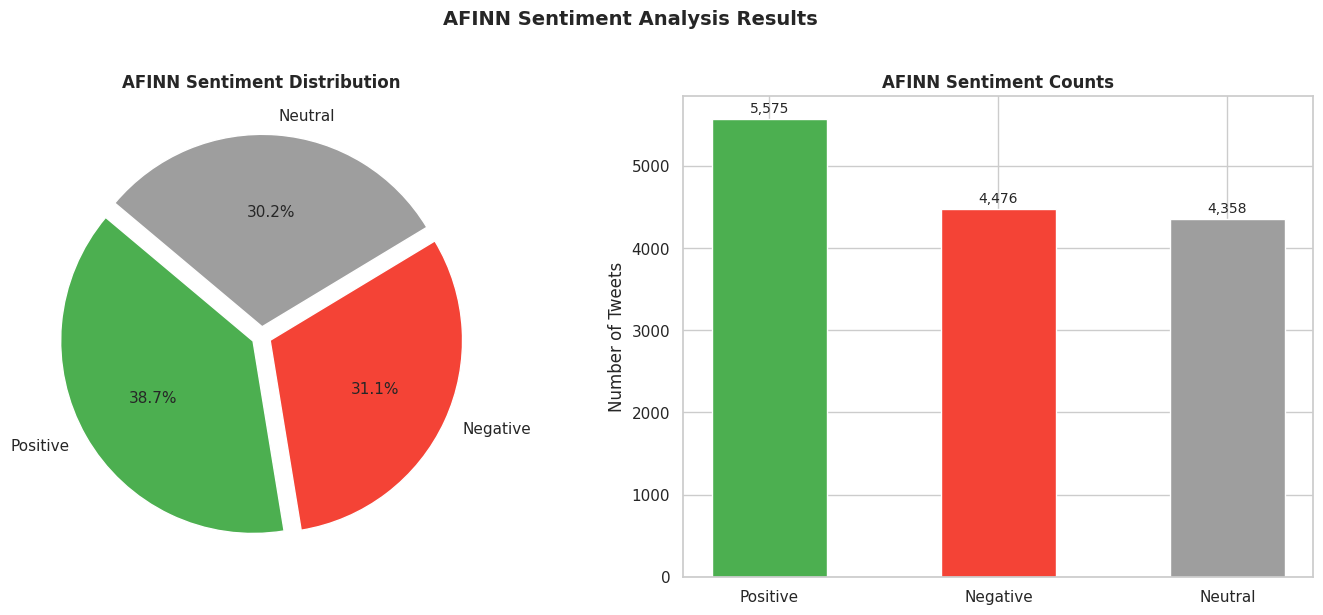

In [ ]:
# Visualise AFINN results

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
labels_a = afinn_counts.index.tolist()
values_a = afinn_counts.values.tolist()

axes[0].pie(
    values_a,
    labels=labels_a,
    autopct='%1.1f%%',
    colors=[colors_map.get(l, '#888') for l in labels_a],
    startangle=140,
    explode=[0.05] * len(labels_a)
)
axes[0].set_title('AFINN Sentiment Distribution', fontsize=12, fontweight='bold')

axes[1].bar(
    labels_a,
    values_a,
    color=[colors_map.get(l, '#888') for l in labels_a],
    edgecolor='white',
    width=0.5
)
axes[1].set_title('AFINN Sentiment Counts', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Tweets')

for i, (l, v) in enumerate(zip(labels_a, values_a)):
    axes[1].text(i, v + 80, f'{v:,}', ha='center', fontsize=10)

plt.suptitle('AFINN Sentiment Analysis Results', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Ground Truth Label Check

This section checks how the lexicon models agree with the rule-based ground truth label. The ground truth is created first using airline keyword rules after preprocessing. The lexicon models are only used for comparison.

Lexicon agreement with rule-based ground truth:


,Model,Approach,Score_Type,Agreement,F1_Macro,F1_Weighted
2,AFINN,Lexicon,Agreement with rule-based ground truth,0.5949,0.5930,0.5990
1,VADER,Lexicon,Agreement with rule-based ground truth,0.5530,0.5497,0.5572
0,TextBlob,Lexicon,Agreement with rule-based ground truth,0.5324,0.5292,0.5325


Best lexicon baseline: AFINN (0.5949)


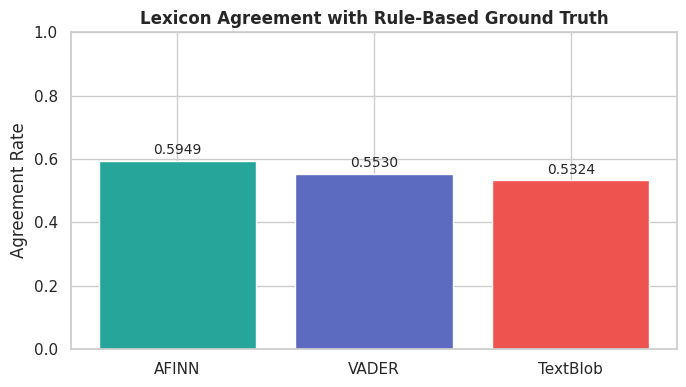

In [ ]:
# Compare lexicon outputs with the rule-based ground truth

from sklearn.metrics import accuracy_score, f1_score, classification_report

lexicon_eval_rows = []
for method, col in [
    ('TextBlob', 'textblob_sentiment'),
    ('VADER', 'vader_sentiment'),
    ('AFINN', 'afinn_sentiment')
]:
    lexicon_eval_rows.append({
        'Model': method,
        'Approach': 'Lexicon',
        'Score_Type': 'Agreement with rule-based ground truth',
        'Agreement': accuracy_score(df['ground_truth_sentiment'], df[col]),
        'F1_Macro': f1_score(df['ground_truth_sentiment'], df[col], average='macro', zero_division=0),
        'F1_Weighted': f1_score(df['ground_truth_sentiment'], df[col], average='weighted', zero_division=0)
    })

lexicon_eval = pd.DataFrame(lexicon_eval_rows).sort_values('Agreement', ascending=False)

print('Lexicon agreement with rule-based ground truth:')
display(lexicon_eval.round(4))

best_lexicon_name = lexicon_eval.iloc[0]['Model']
best_lexicon_score = lexicon_eval.iloc[0]['Agreement']

print(f'Best lexicon baseline: {best_lexicon_name} ({best_lexicon_score:.4f})')

plt.figure(figsize=(7, 4))
bars = plt.bar(
    lexicon_eval['Model'],
    lexicon_eval['Agreement'],
    color=['#26A69A', '#5C6BC0', '#EF5350']
)
plt.title('Lexicon Agreement with Rule-Based Ground Truth', fontsize=12, fontweight='bold')
plt.ylabel('Agreement Rate')
plt.ylim(0, 1)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{bar.get_height():.4f}',
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [ ]:
# Show detailed report for the best lexicon baseline

lexicon_col_map = {
    'TextBlob': 'textblob_sentiment',
    'VADER': 'vader_sentiment',
    'AFINN': 'afinn_sentiment'
}

selected_col = lexicon_col_map[best_lexicon_name]

print(f'{best_lexicon_name} vs rule-based ground truth:')
print(classification_report(df['ground_truth_sentiment'], df[selected_col], zero_division=0))

AFINN vs rule-based ground truth:
              precision    recall  f1-score   support

    Negative       0.73      0.58      0.65      5634
     Neutral       0.71      0.48      0.57      6472
    Positive       0.40      0.96      0.56      2303

    accuracy                           0.59     14409
   macro avg       0.61      0.67      0.59     14409
weighted avg       0.67      0.59      0.60     14409



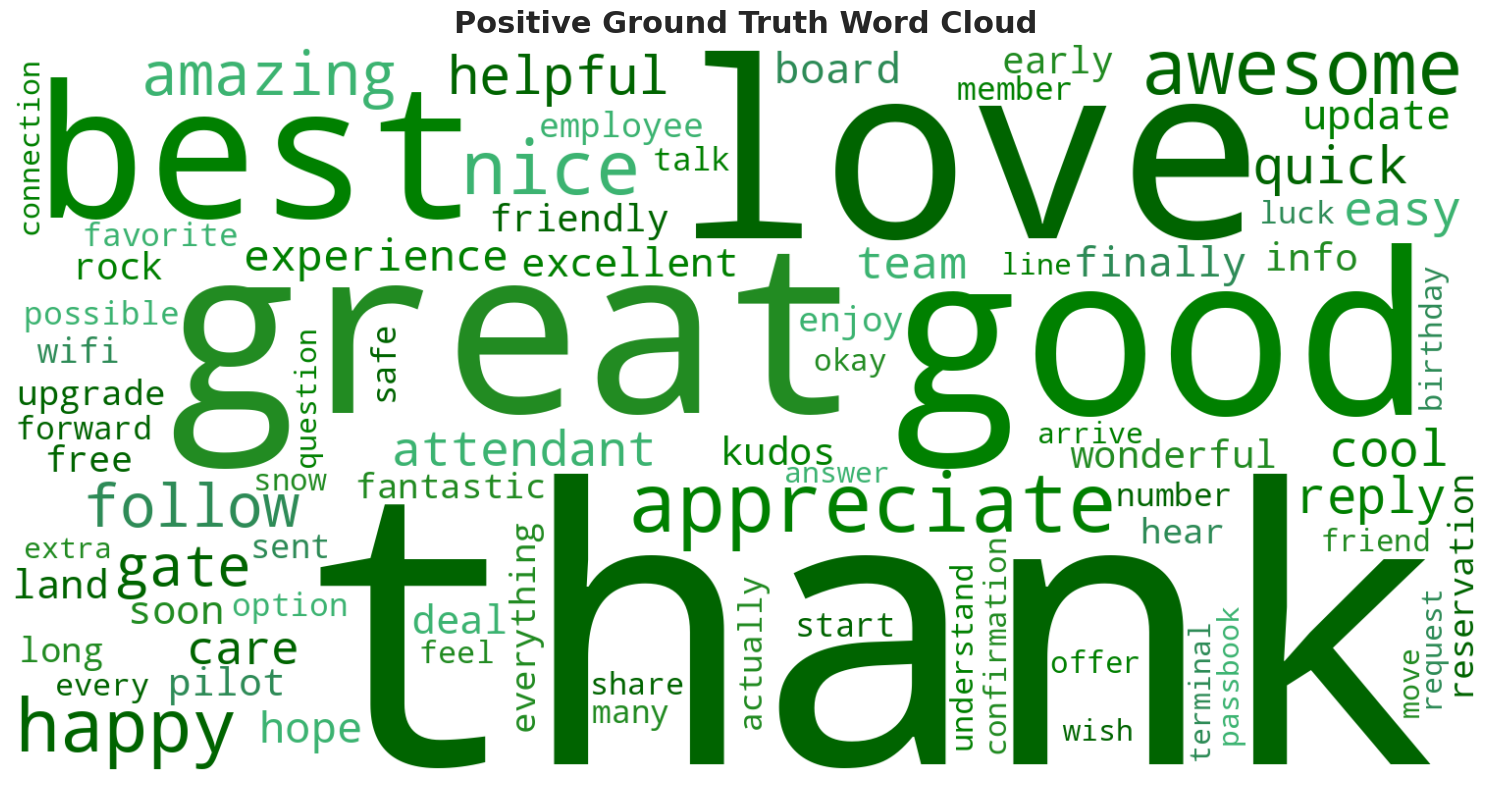

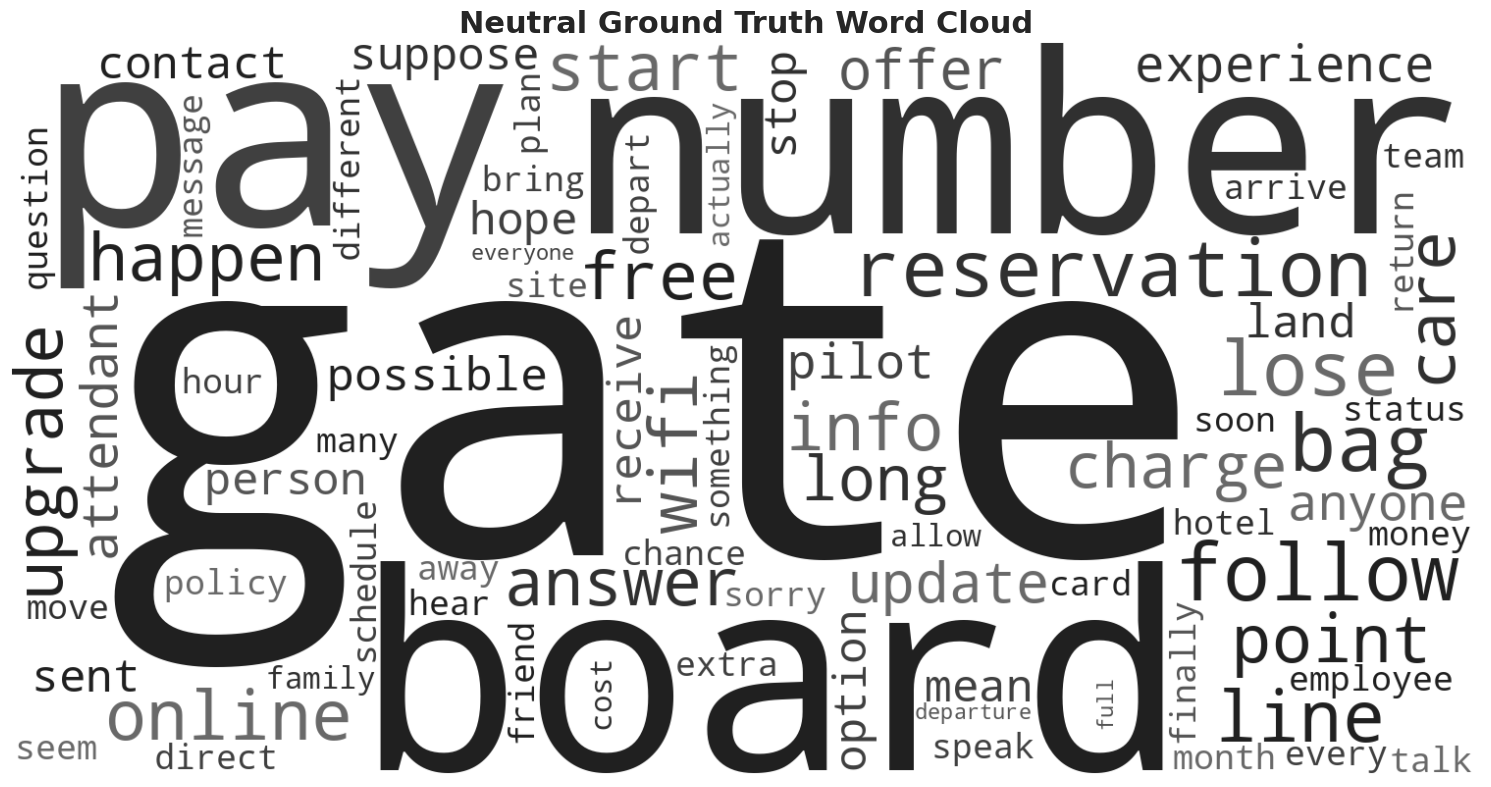

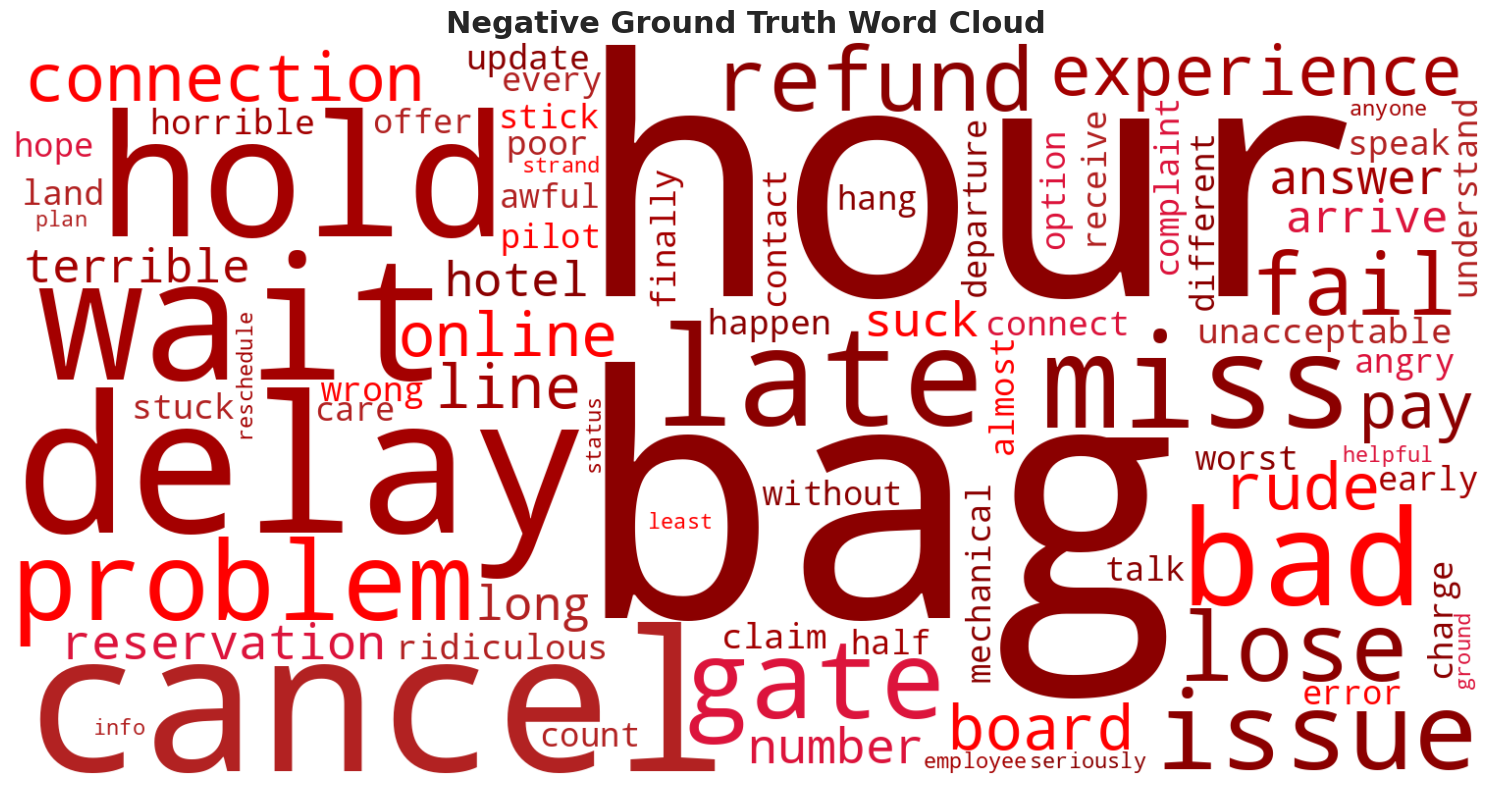

In [ ]:
sentiment_color_palettes = {
    'Positive': ['#006400', '#008000', '#228B22', '#2E8B57', '#3CB371'],
    'Neutral': ['#202020', '#303030', '#404040', '#555555', '#696969'],
    'Negative': ['#8B0000', '#A40000', '#B22222', '#DC143C', '#FF0000']
}


def make_color_func(palette):
    def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
        if random_state is None:
            return palette[0]
        return palette[random_state.randint(0, len(palette) - 1)]
    return color_func


sentiment_wordcloud_configs = [
    ('Positive Ground Truth Word Cloud', df[df['ground_truth_sentiment'] == 'Positive'], 'Positive'),
    ('Neutral Ground Truth Word Cloud', df[df['ground_truth_sentiment'] == 'Neutral'], 'Neutral'),
    ('Negative Ground Truth Word Cloud', df[df['ground_truth_sentiment'] == 'Negative'], 'Negative')
]

for title, subset, sentiment in sentiment_wordcloud_configs:
    text = get_wordcloud_text(subset, sentiment=sentiment)
    if text.strip():
        wc = WordCloud(
            width=1500,
            height=750,
            background_color='white',
            stopwords=wordcloud_stopwords,
            max_words=80,
            collocations=False,
            prefer_horizontal=0.95,
            min_font_size=9,
            relative_scaling=0.45,
            margin=5,
            random_state=42
        ).generate(text)

        wc = wc.recolor(color_func=make_color_func(sentiment_color_palettes[sentiment]), random_state=42)

        plt.figure(figsize=(16, 8))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(title, fontsize=22, fontweight='bold')
        plt.tight_layout()
        plt.show()


---
# Segment 6: Feature Engineering
TF-IDF, Word2Vec and DistilBERT contextual embeddings are prepared for text representation.

In [ ]:
feature_text = df['final_processed_text'].fillna('').astype(str)
target_label = df['label'].astype(str)

# TF-IDF overview uses the cleaned text and removes common noise words
tfidf_overview = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    stop_words=list(tfidf_noise_words)
)
X_tfidf_overview = tfidf_overview.fit_transform(feature_text)

print("TF-IDF overview matrix shape:", X_tfidf_overview.shape)
print("\nGround truth sentiment label distribution:")
print(target_label.value_counts())


TF-IDF overview matrix shape: (14409, 50000)

Ground truth sentiment label distribution:
label
Neutral     6472
Negative    5634
Positive    2303
Name: count, dtype: int64


In [ ]:
from gensim.models import Word2Vec

sentences = [tokens for tokens in df['lemmatized'] if len(tokens) > 0]

w2v_model = Word2Vec(
    sentences  = sentences,
    vector_size= 100,
    window     = 5,
    min_count  = 2,
    sg         = 1,      # Skip-Gram architecture
    epochs     = 10,
    workers    = 4,
    seed       = 42
)

print(f"Word2Vec vocabulary size: {len(w2v_model.wv):,} words")
print(f"Embedding dimensions:     {w2v_model.vector_size}")

print("\nWords most similar to 'delay':")
try:
    print(w2v_model.wv.most_similar('delay', topn=5))
except KeyError:
    print("  'delay' not in vocabulary")

print("\nWords most similar to 'service':")
try:
    print(w2v_model.wv.most_similar('service', topn=5))
except KeyError:
    print("  'service' not in vocabulary")

Word2Vec vocabulary size: 4,673 words
Embedding dimensions:     100

Words most similar to 'delay':
[('charleston', 0.8094133138656616), ('arrival', 0.8063764572143555), ('backup', 0.8023782968521118), ('inbound', 0.7954940795898438), ('traffic', 0.7943176031112671)]

Words most similar to 'service':
[('svc', 0.8047427535057068), ('absolute', 0.7817058563232422), ('intentionally', 0.7526283860206604), ('neveragain', 0.7472597360610962), ('customerservice', 0.7471492886543274)]


Word2Vec feature matrix shape: (14409, 100)


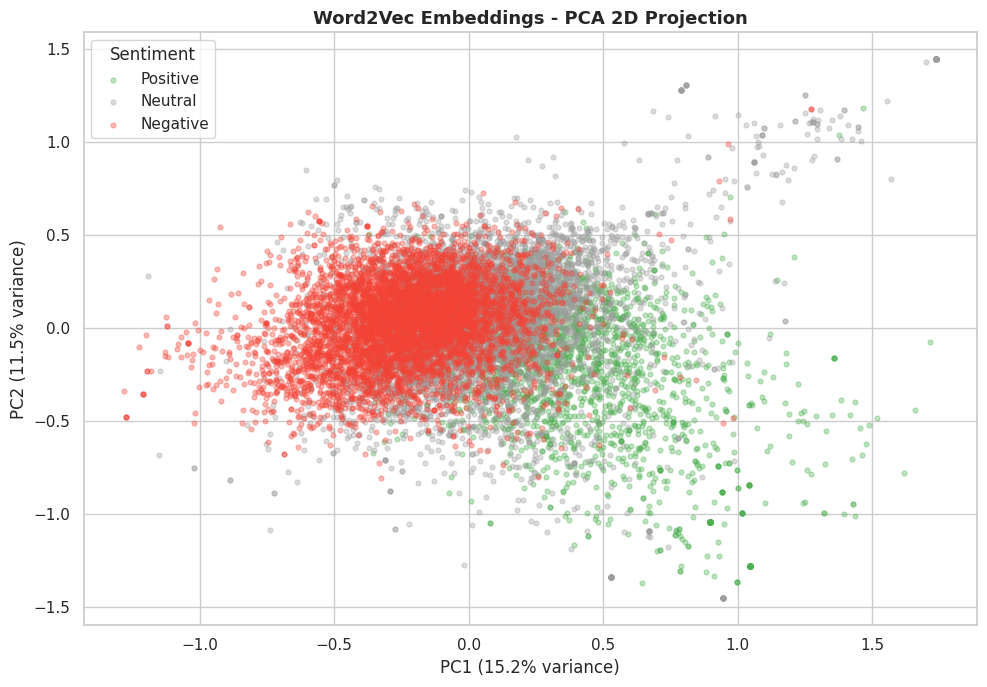

In [ ]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split


def get_w2v_vector(tokens, model, size=100):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)


X_w2v = np.array([get_w2v_vector(toks, w2v_model) for toks in df['lemmatized']])
print(f"Word2Vec feature matrix shape: {X_w2v.shape}")

pca       = PCA(n_components=2, random_state=42)
X_w2v_2d  = pca.fit_transform(X_w2v)
y_w2v     = df['label'].values

plt.figure(figsize=(10, 7))
scatter_c = {'Positive': '#4CAF50', 'Neutral': '#9E9E9E', 'Negative': '#F44336'}
for label in ['Positive', 'Neutral', 'Negative']:
    mask = y_w2v == label
    plt.scatter(X_w2v_2d[mask, 0], X_w2v_2d[mask, 1],
                c=scatter_c[label], label=label, alpha=0.35, s=12)
plt.title('Word2Vec Embeddings - PCA 2D Projection',
          fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Sentiment', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
import torch
from transformers import DistilBertTokenizerFast, DistilBertModel

print("Loading DistilBERT for contextual embedding extraction...")
bert_tok_fe = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
bert_model_fe = DistilBertModel.from_pretrained('distilbert-base-uncased')
bert_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model_fe.to(bert_device)
bert_model_fe.eval()

BERT_EMBED_BATCH_SIZE = 32 if torch.cuda.is_available() else 8


def get_bert_cls_embeddings(texts, tok, model, device, batch_size=8, max_len=64):
    embeddings = []
    texts = [str(t) for t in texts]
    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        inputs = tok(
            batch_texts,
            return_tensors='pt',
            truncation=True,
            padding=True,
            max_length=max_len
        )
        inputs = {key: val.to(device) for key, val in inputs.items()}
        with torch.no_grad():
            out = model(**inputs)
        embeddings.append(out.last_hidden_state[:, 0, :].cpu().numpy())
    return np.vstack(embeddings)

bert_texts = df['text'].astype(str).tolist()
bert_embeds = get_bert_cls_embeddings(
    bert_texts,
    bert_tok_fe,
    bert_model_fe,
    bert_device,
    batch_size=BERT_EMBED_BATCH_SIZE,
    max_len=64
)

print(f"Contextual embedding matrix shape: {bert_embeds.shape}")
print(f"Device used: {bert_device}")

Loading DistilBERT for contextual embedding extraction...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Contextual embedding matrix shape: (14409, 768)
Device used: cuda


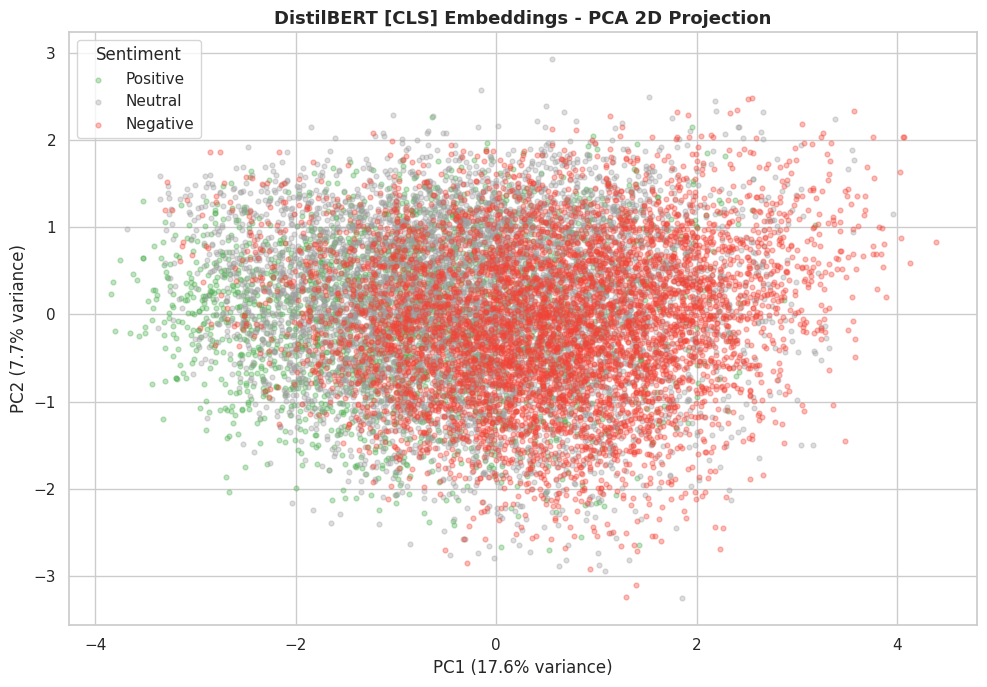

BERT embedding extraction completed.


In [ ]:
pca_bert    = PCA(n_components=2, random_state=42)
bert_2d     = pca_bert.fit_transform(bert_embeds)
bert_labels = df['label'].values

plt.figure(figsize=(10, 7))
for label in ['Positive', 'Neutral', 'Negative']:
    mask = bert_labels == label
    plt.scatter(bert_2d[mask, 0], bert_2d[mask, 1],
                c=scatter_c[label], label=label, alpha=0.35, s=12)
plt.title('DistilBERT [CLS] Embeddings - PCA 2D Projection',
          fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca_bert.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_bert.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Sentiment', fontsize=11)
plt.tight_layout()
plt.show()
print("BERT embedding extraction completed.")

---
# Segment 7: Traditional Machine Learning
Logistic Regression and Linear SVM are trained using TF-IDF features. The vectorizer and SMOTE are fitted inside the training pipeline.

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

X_text = df['final_processed_text'].fillna('').astype(str)
y = df['label'].astype(str)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", len(X_train_text))
print("Testing set size:", len(X_test_text))
print("\nTraining class distribution:")
print(y_train.value_counts())

Training set size: 11527
Testing set size: 2882

Training class distribution:
label
Neutral     5178
Negative    4507
Positive    1842
Name: count, dtype: int64


Training shape before SMOTE: (11527, 50000)
Training shape after SMOTE : (15534, 50000)


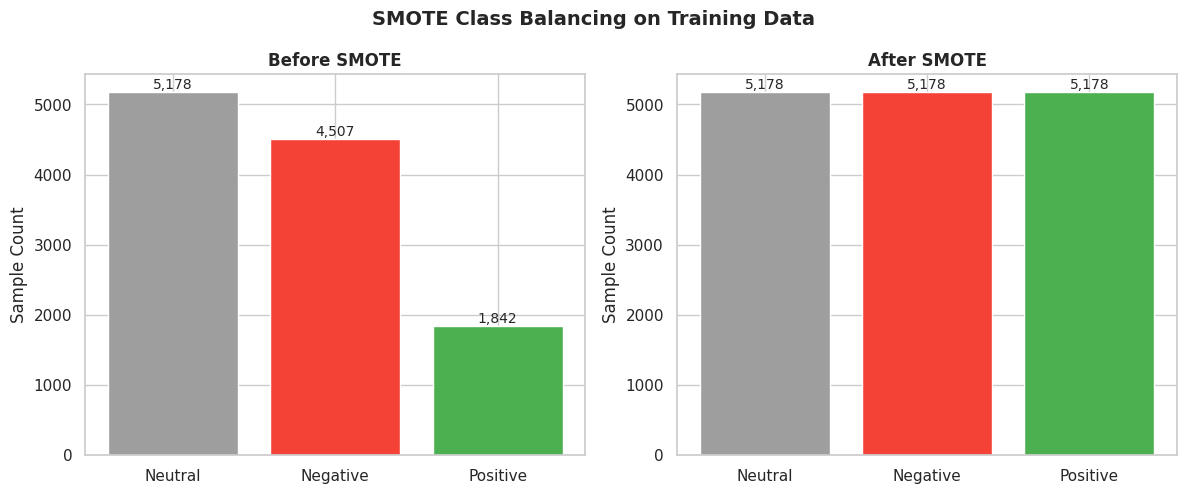

In [ ]:
tfidf_smote_preview = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_train_preview = tfidf_smote_preview.fit_transform(X_train_text)
smote_preview = SMOTE(random_state=42, k_neighbors=5)
X_train_sm_preview, y_train_sm_preview = smote_preview.fit_resample(X_train_preview, y_train)

print(f"Training shape before SMOTE: {X_train_preview.shape}")
print(f"Training shape after SMOTE : {X_train_sm_preview.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
before_counts = y_train.value_counts()
after_counts = pd.Series(y_train_sm_preview).value_counts()

for ax, counts, title in [
    (axes[0], before_counts, 'Before SMOTE'),
    (axes[1], after_counts, 'After SMOTE'),
]:
    bar_c = [colors_map.get(l, '#888') for l in counts.index]
    bars = ax.bar(counts.index, counts.values, color=bar_c, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Sample Count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 50, f'{val:,}', ha='center', fontsize=10)

plt.suptitle('SMOTE Class Balancing on Training Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("Running GridSearchCV for Logistic Regression...")

lr_pipeline = ImbPipeline([
    ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf', LogisticRegression(random_state=42))
])

lr_param_grid = {
    'clf__C': [0.1, 1.0, 10.0],
    'clf__max_iter': [500, 1000],
    'clf__solver': ['lbfgs', 'saga'],
}

cv_split = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_grid = GridSearchCV(
    lr_pipeline,
    param_grid=lr_param_grid,
    cv=cv_split,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train_text, y_train)

print(f"Best LR Parameters: {lr_grid.best_params_}")
print(f"Best CV F1-weighted: {lr_grid.best_score_:.4f}")

Running GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best LR Parameters: {'clf__C': 10.0, 'clf__max_iter': 500, 'clf__solver': 'lbfgs'}
Best CV F1-weighted: 0.9209


In [ ]:
print("Running GridSearchCV for Linear SVM...")

svm_pipeline = ImbPipeline([
    ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf', LinearSVC(random_state=42))
])

svm_param_grid = {
    'clf__C': [0.1, 1.0, 5.0],
    'clf__max_iter': [1000, 2000],
}

svm_grid = GridSearchCV(
    svm_pipeline,
    param_grid=svm_param_grid,
    cv=cv_split,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
svm_grid.fit(X_train_text, y_train)

print(f"Best SVM Parameters: {svm_grid.best_params_}")
print(f"Best CV F1-weighted: {svm_grid.best_score_:.4f}")

Running GridSearchCV for Linear SVM...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best SVM Parameters: {'clf__C': 1.0, 'clf__max_iter': 1000}
Best CV F1-weighted: 0.9239


In [ ]:
best_lr = lr_grid.best_estimator_
best_svm = svm_grid.best_estimator_

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(best_lr, X_train_text, y_train, cv=kfold, scoring='accuracy', n_jobs=-1)
svm_cv_scores = cross_val_score(best_svm, X_train_text, y_train, cv=kfold, scoring='accuracy', n_jobs=-1)

print("=" * 55)
print("k-Fold Cross-Validation Results")
print("=" * 55)
print(f"\nLogistic Regression:")
print(f"  Fold Accuracies: {[f'{s:.4f}' for s in lr_cv_scores]}")
print(f"  Mean Accuracy  : {lr_cv_scores.mean():.4f}")
print(f"  Std Deviation  : {lr_cv_scores.std():.4f}")
print(f"\nLinear SVM:")
print(f"  Fold Accuracies: {[f'{s:.4f}' for s in svm_cv_scores]}")
print(f"  Mean Accuracy  : {svm_cv_scores.mean():.4f}")
print(f"  Std Deviation  : {svm_cv_scores.std():.4f}")

k-Fold Cross-Validation Results

Logistic Regression:
  Fold Accuracies: ['0.9211', '0.9163', '0.9197', '0.9267', '0.9206']
  Mean Accuracy  : 0.9209
  Std Deviation  : 0.0033

Linear SVM:
  Fold Accuracies: ['0.9228', '0.9202', '0.9236', '0.9289', '0.9241']
  Mean Accuracy  : 0.9239
  Std Deviation  : 0.0028


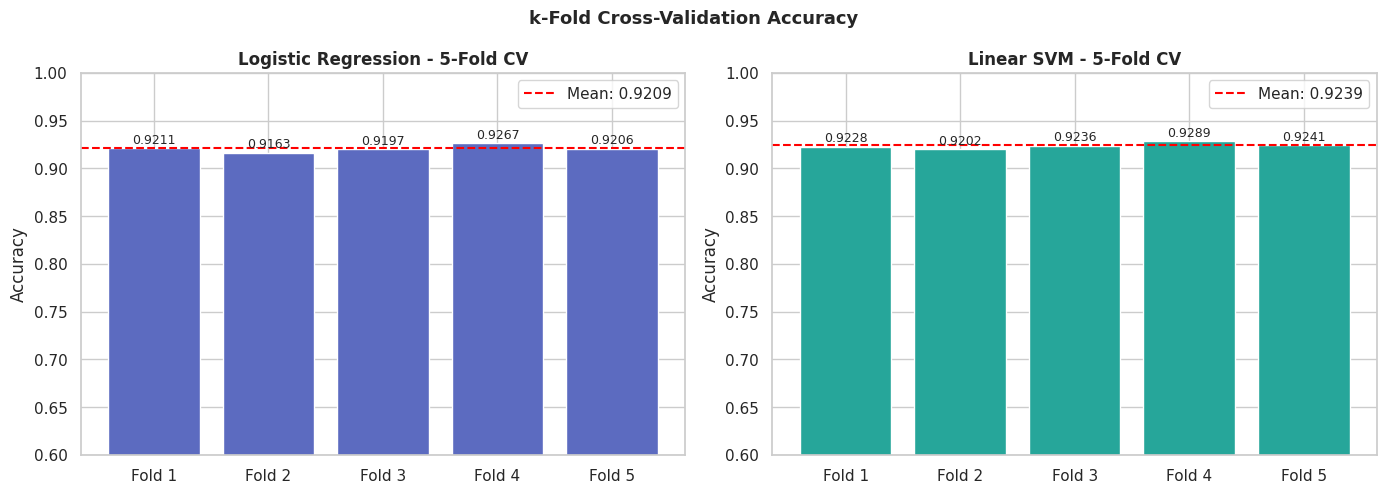

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
folds = [f'Fold {i+1}' for i in range(5)]

for ax, scores, title, color in [
    (axes[0], lr_cv_scores,  'Logistic Regression - 5-Fold CV', '#5C6BC0'),
    (axes[1], svm_cv_scores, 'Linear SVM - 5-Fold CV',          '#26A69A'),
]:
    ax.bar(folds, scores, color=color, edgecolor='white')
    ax.axhline(scores.mean(), color='red', linestyle='--',
               label=f'Mean: {scores.mean():.4f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.6, 1.0)
    ax.legend()
    for i, v in enumerate(scores):
        ax.text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('k-Fold Cross-Validation Accuracy',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
y_pred_lr = best_lr.predict(X_test_text)
y_pred_svm = best_svm.predict(X_test_text)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("=" * 50)
print("LOGISTIC REGRESSION - Test Set Results")
print("=" * 50)
print(f"Test Accuracy : {lr_accuracy:.4f}")
print(f"CV Mean Acc   : {lr_cv_scores.mean():.4f}")
print(f"Gap           : {abs(lr_accuracy - lr_cv_scores.mean()):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\n" + "=" * 50)
print("LINEAR SVM - Test Set Results")
print("=" * 50)
print(f"Test Accuracy : {svm_accuracy:.4f}")
print(f"CV Mean Acc   : {svm_cv_scores.mean():.4f}")
print(f"Gap           : {abs(svm_accuracy - svm_cv_scores.mean()):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

LOGISTIC REGRESSION - Test Set Results
Test Accuracy : 0.9264
CV Mean Acc   : 0.9209
Gap           : 0.0056

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.97      0.95      1127
     Neutral       0.94      0.90      0.92      1294
    Positive       0.85      0.90      0.87       461

    accuracy                           0.93      2882
   macro avg       0.91      0.92      0.92      2882
weighted avg       0.93      0.93      0.93      2882


LINEAR SVM - Test Set Results
Test Accuracy : 0.9323
CV Mean Acc   : 0.9239
Gap           : 0.0084

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.97      0.95      1127
     Neutral       0.96      0.90      0.93      1294
    Positive       0.85      0.94      0.89       461

    accuracy                           0.93      2882
   macro avg       0.92      0.94      0.93      2882
weighted avg       0.93      0.93    

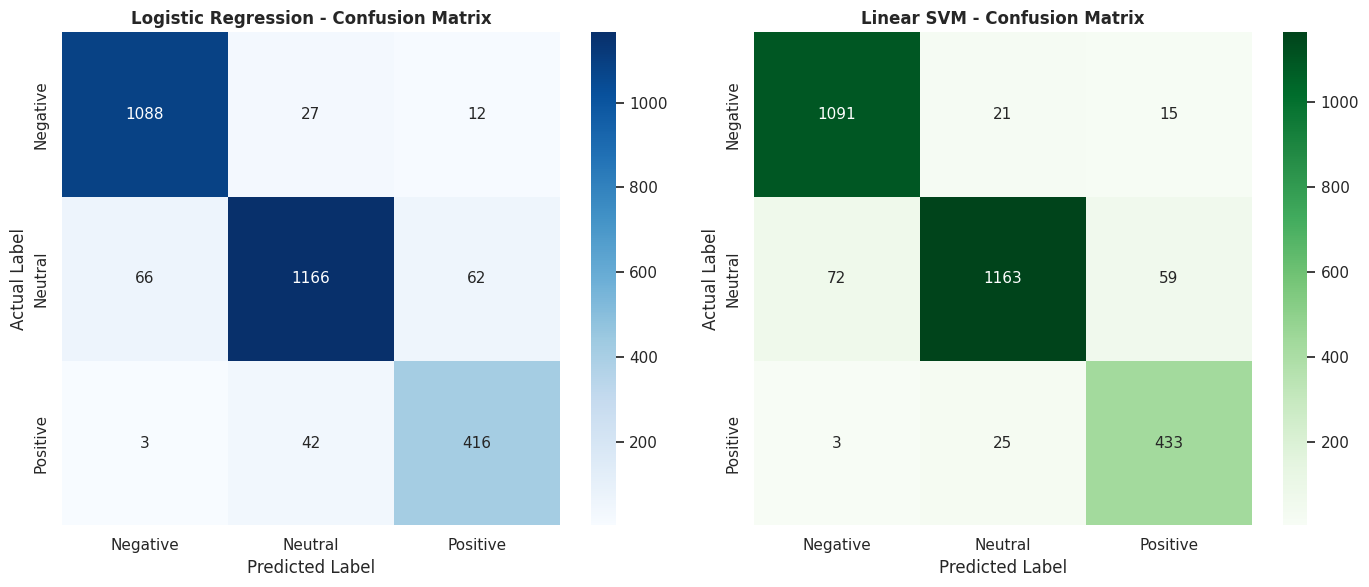

LR  - Macro F1: 0.9166  | Weighted F1: 0.9265
SVM - Macro F1: 0.9252  | Weighted F1: 0.9325


In [ ]:
class_labels = ['Negative', 'Neutral', 'Positive']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, title, cmap in [
    (axes[0], y_pred_lr,  'Logistic Regression - Confusion Matrix', 'Blues'),
    (axes[1], y_pred_svm, 'Linear SVM - Confusion Matrix',          'Greens'),
]:
    cm = confusion_matrix(y_test, y_pred, labels=class_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=class_labels, yticklabels=class_labels, ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('Actual Label')

plt.tight_layout()
plt.show()

lr_f1_macro     = f1_score(y_test, y_pred_lr,  average='macro')
lr_f1_weighted  = f1_score(y_test, y_pred_lr,  average='weighted')
svm_f1_macro    = f1_score(y_test, y_pred_svm, average='macro')
svm_f1_weighted = f1_score(y_test, y_pred_svm, average='weighted')

print(f"LR  - Macro F1: {lr_f1_macro:.4f}  | Weighted F1: {lr_f1_weighted:.4f}")
print(f"SVM - Macro F1: {svm_f1_macro:.4f}  | Weighted F1: {svm_f1_weighted:.4f}")

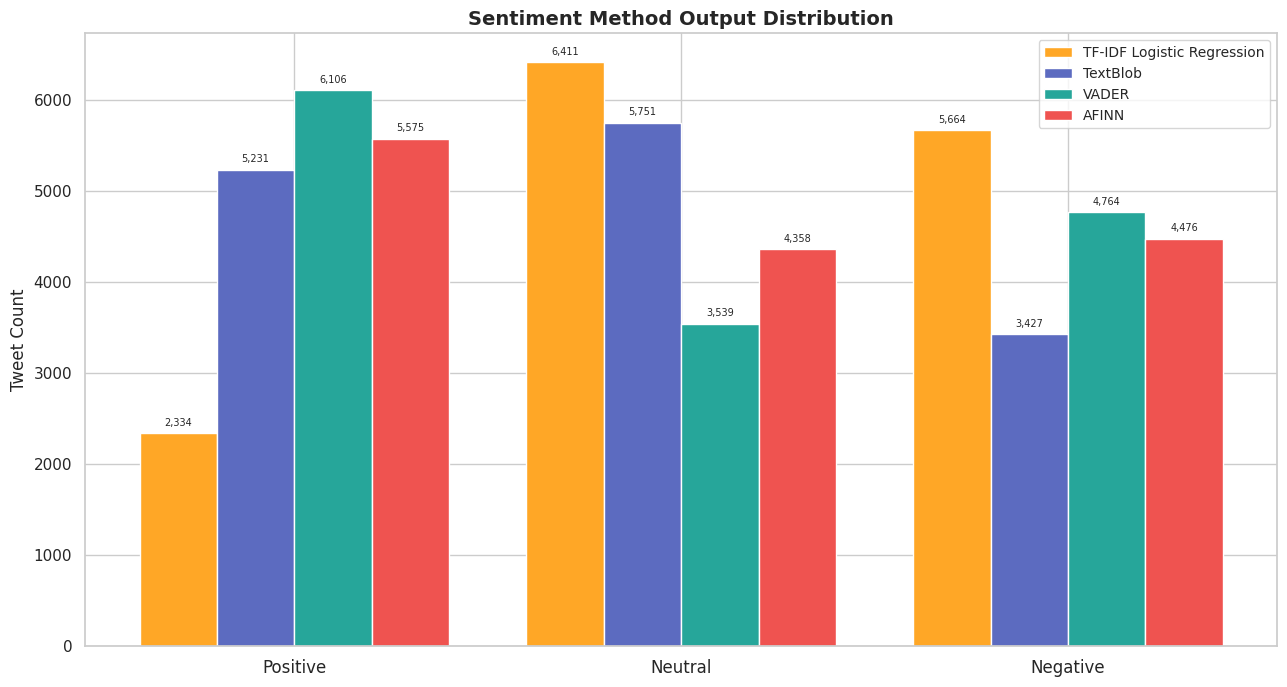

Method output distribution summary:
                    Method  Positive  Neutral  Negative
TF-IDF Logistic Regression      2334     6411      5664
                  TextBlob      5231     5751      3427
                     VADER      6106     3539      4764
                     AFINN      5575     4358      4476


In [ ]:
df['tfidf_lr_sentiment'] = best_lr.predict(df['final_processed_text'].fillna('').astype(str))

tfidf_vals = [df['tfidf_lr_sentiment'].value_counts().get(s, 0) for s in sent_order]
tb_vals = [df['textblob_raw_sentiment'].value_counts().get(s, 0) for s in sent_order]
vader_vals = [df['vader_sentiment'].value_counts().get(s, 0) for s in sent_order]
afinn_vals = [df['afinn_sentiment'].value_counts().get(s, 0) for s in sent_order]

x = np.arange(3)
width = 0.2
fig, ax = plt.subplots(figsize=(13, 7))
b0 = ax.bar(x - 1.5*width, tfidf_vals, width, label='TF-IDF Logistic Regression', color='#FFA726')
b1 = ax.bar(x - 0.5*width, tb_vals, width, label='TextBlob', color='#5C6BC0')
b2 = ax.bar(x + 0.5*width, vader_vals, width, label='VADER', color='#26A69A')
b3 = ax.bar(x + 1.5*width, afinn_vals, width, label='AFINN', color='#EF5350')

ax.set_xticks(x)
ax.set_xticklabels(sent_order, fontsize=12)
ax.set_title('Sentiment Method Output Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Tweet Count')
ax.legend(fontsize=10)

for bars in [b0, b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 60,
                f'{int(bar.get_height()):,}',
                ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

four_method_summary = pd.DataFrame({
    'Method': ['TF-IDF Logistic Regression', 'TextBlob', 'VADER', 'AFINN'],
    'Positive': [df['tfidf_lr_sentiment'].value_counts().get('Positive', 0),
                 df['textblob_raw_sentiment'].value_counts().get('Positive', 0),
                 df['vader_sentiment'].value_counts().get('Positive', 0),
                 df['afinn_sentiment'].value_counts().get('Positive', 0)],
    'Neutral': [df['tfidf_lr_sentiment'].value_counts().get('Neutral', 0),
                df['textblob_raw_sentiment'].value_counts().get('Neutral', 0),
                df['vader_sentiment'].value_counts().get('Neutral', 0),
                df['afinn_sentiment'].value_counts().get('Neutral', 0)],
    'Negative': [df['tfidf_lr_sentiment'].value_counts().get('Negative', 0),
                 df['textblob_raw_sentiment'].value_counts().get('Negative', 0),
                 df['vader_sentiment'].value_counts().get('Negative', 0),
                 df['afinn_sentiment'].value_counts().get('Negative', 0)],
})
print("Method output distribution summary:")
print(four_method_summary.to_string(index=False))

---
# Segment 8: Deep Learning Model
A BiLSTM model is trained using padded token sequences.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

# fixed seed for stable run
tf.random.set_seed(42)
np.random.seed(42)
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [ ]:
texts_dl = df['final_processed_text'].fillna('').astype(str).values
labels_dl = df['label'].astype(str).values

train_texts_dl, temp_texts_dl, train_labels_dl, temp_labels_dl = train_test_split(
    texts_dl,
    labels_dl,
    test_size=0.30,
    random_state=42,
    stratify=labels_dl
)

val_texts_dl, test_texts_dl, val_labels_dl, test_labels_dl = train_test_split(
    temp_texts_dl,
    temp_labels_dl,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels_dl
)

MAX_VOCAB = 15000
MAX_LEN = 60

# tokenizer fitted on train text only
keras_tok = KerasTokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
keras_tok.fit_on_texts(train_texts_dl)

train_seqs_dl = keras_tok.texts_to_sequences(train_texts_dl)
val_seqs_dl = keras_tok.texts_to_sequences(val_texts_dl)
test_seqs_dl = keras_tok.texts_to_sequences(test_texts_dl)

X_train_dl = pad_sequences(train_seqs_dl, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_dl = pad_sequences(val_seqs_dl, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_dl = pad_sequences(test_seqs_dl, maxlen=MAX_LEN, padding='post', truncating='post')

le_dl = LabelEncoder()
y_train_dl = le_dl.fit_transform(train_labels_dl)
y_val_dl = le_dl.transform(val_labels_dl)
y_test_dl = le_dl.transform(test_labels_dl)

print(f"Vocabulary size: {len(keras_tok.word_index):,}")
print(f"BiLSTM training shape:   {X_train_dl.shape}")
print(f"BiLSTM validation shape: {X_val_dl.shape}")
print(f"BiLSTM testing shape:    {X_test_dl.shape}")
print("Label order:", list(le_dl.classes_))

classes_dl = np.unique(y_train_dl)
class_weights_dl = compute_class_weight(
    class_weight='balanced',
    classes=classes_dl,
    y=y_train_dl
)
class_weight_dict = dict(zip(classes_dl, class_weights_dl))
print("Class weights:", class_weight_dict)

Vocabulary size: 8,931
BiLSTM training shape:   (10086, 60)
BiLSTM validation shape: (2161, 60)
BiLSTM testing shape:    (2162, 60)
Label order: ['Negative', 'Neutral', 'Positive']
Class weights: {np.int64(0): np.float64(0.8524340770791075), np.int64(1): np.float64(0.7421633554083885), np.int64(2): np.float64(2.0856079404466503)}


In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_dl),
    y=y_train_dl
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.8524340770791075), 1: np.float64(0.7421633554083885), 2: np.float64(2.0856079404466503)}


In [ ]:
EMBED_DIM = 88
NUM_CLASSES = 3

bilstm_model = Sequential(name='BiLSTM_Text_Classifier')
bilstm_model.add(Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN))
bilstm_model.add(SpatialDropout1D(0.28))
bilstm_model.add(Bidirectional(LSTM(
    36,
    dropout=0.28,
    recurrent_dropout=0.12,
    kernel_regularizer=l2(0.0008),
    recurrent_regularizer=l2(0.0008)
)))
bilstm_model.add(Dense(36, activation='relu', kernel_regularizer=l2(0.0008)))
bilstm_model.add(Dropout(0.40))
bilstm_model.add(Dense(NUM_CLASSES, activation='softmax'))

bilstm_model.compile(
    optimizer=Adam(learning_rate=0.0008),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("BiLSTM model architecture:")
bilstm_model.summary()

BiLSTM model architecture:


Model: "BiLSTM_Text_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    min_delta=0.001,
    mode='min',
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

history_dl = bilstm_model.fit(
    X_train_dl, y_train_dl,
    epochs=8,
    batch_size=256,
    validation_data=(X_val_dl, y_val_dl),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

best_epoch_index = int(np.argmin(history_dl.history['val_loss']))
bilstm_train_accuracy = float(history_dl.history['accuracy'][best_epoch_index])
bilstm_val_accuracy = float(history_dl.history['val_accuracy'][best_epoch_index])
bilstm_overfit_gap = max(bilstm_train_accuracy - bilstm_val_accuracy, 0)

if bilstm_overfit_gap <= 0.08:
    bilstm_fit_status = 'Low gap'
elif bilstm_overfit_gap <= 0.12:
    bilstm_fit_status = 'Acceptable gap'
else:
    bilstm_fit_status = 'Noticeable gap'

print("BiLSTM training complete.")
print(f"Best epoch: {best_epoch_index + 1}")
print(f"Training accuracy at best epoch: {bilstm_train_accuracy:.4f}")
print(f"Validation accuracy at best epoch: {bilstm_val_accuracy:.4f}")
print(f"Training-validation gap: {bilstm_overfit_gap:.4f}")
print(f"Assessment: {bilstm_fit_status}")

Epoch 1/8
40/40 ━━━━━━━━━━━━━━━━━━━━ 38s 494ms/step - accuracy: 0.3699 - loss: 1.2920 - val_accuracy: 0.4368 - val_loss: 1.1919 - learning_rate: 8.0000e-04
Epoch 2/8
40/40 ━━━━━━━━━━━━━━━━━━━━ 34s 447ms/step - accuracy: 0.5855 - loss: 0.9970 - val_accuracy: 0.8181 - val_loss: 0.7446 - learning_rate: 8.0000e-04
Epoch 3/8
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 459ms/step - accuracy: 0.8453 - loss: 0.5712 - val_accuracy: 0.9218 - val_loss: 0.4216 - learning_rate: 8.0000e-04
Epoch 4/8
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 482ms/step - accuracy: 0.9312 - loss: 0.3627 - val_accuracy: 0.9472 - val_loss: 0.3126 - learning_rate: 8.0000e-04
Epoch 5/8
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 451ms/step - accuracy: 0.9570 - loss: 0.2769 - val_accuracy: 0.9560 - val_loss: 0.2731 - learning_rate: 8.0000e-04
Epoch 6/8
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 437ms/step - accuracy: 0.9677 - loss: 0.2310 - val_accuracy: 0.9611 - val_loss: 0.2536 - learning_rate: 8.0000e-04
Epoch 7/8
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 492ms/step - accuracy: 

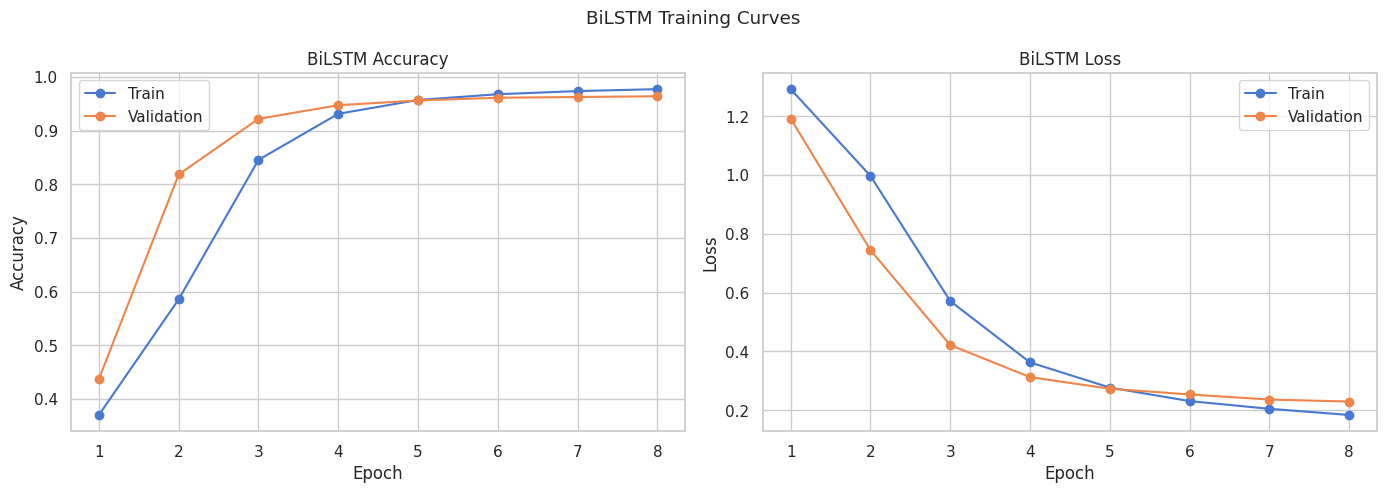

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history_dl.history['accuracy']) + 1)

axes[0].plot(epochs_range, history_dl.history['accuracy'], marker='o', label='Train')
axes[0].plot(epochs_range, history_dl.history['val_accuracy'], marker='o', label='Validation')
axes[0].set_title('BiLSTM Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(epochs_range, history_dl.history['loss'], marker='o', label='Train')
axes[1].plot(epochs_range, history_dl.history['val_loss'], marker='o', label='Validation')
axes[1].set_title('BiLSTM Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('BiLSTM Training Curves')
plt.tight_layout()
plt.show()

BiLSTM Validation Accuracy: 0.9639
BiLSTM Test Accuracy: 0.9524
Training-validation gap: 0.0133
Validation-test gap: 0.0115
Generalisation status: Low gap
BiLSTM Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      0.97      0.96       845
     Neutral       0.96      0.95      0.95       971
    Positive       0.94      0.92      0.93       346

    accuracy                           0.95      2162
   macro avg       0.95      0.95      0.95      2162
weighted avg       0.95      0.95      0.95      2162



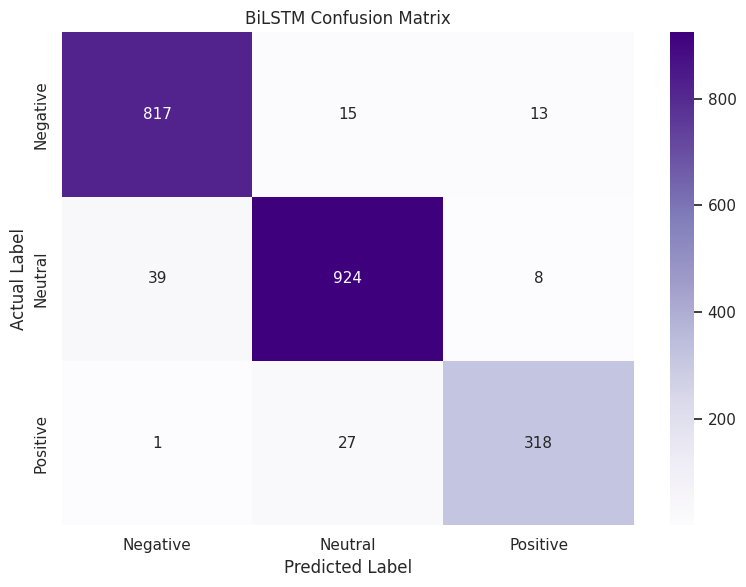

BiLSTM Macro F1: 0.9475
BiLSTM Weighted F1: 0.9523


In [ ]:
y_val_pred_dl_probs = bilstm_model.predict(X_val_dl, verbose=0)
y_val_pred_dl = np.argmax(y_val_pred_dl_probs, axis=1)
bilstm_val_accuracy_eval = accuracy_score(y_val_dl, y_val_pred_dl)

y_pred_dl_probs = bilstm_model.predict(X_test_dl, verbose=0)
y_pred_dl = np.argmax(y_pred_dl_probs, axis=1)
bilstm_accuracy = accuracy_score(y_test_dl, y_pred_dl)
bilstm_val_test_gap = abs(bilstm_val_accuracy_eval - bilstm_accuracy)

bilstm_generalisation_status = 'Low gap' if (bilstm_overfit_gap <= 0.08 and bilstm_val_test_gap <= 0.08) else 'Acceptable gap' if (bilstm_overfit_gap <= 0.12 and bilstm_val_test_gap <= 0.08) else 'Noticeable gap'

print(f"BiLSTM Validation Accuracy: {bilstm_val_accuracy_eval:.4f}")
print(f"BiLSTM Test Accuracy: {bilstm_accuracy:.4f}")
print(f"Training-validation gap: {bilstm_overfit_gap:.4f}")
print(f"Validation-test gap: {bilstm_val_test_gap:.4f}")
print(f"Generalisation status: {bilstm_generalisation_status}")
print("BiLSTM Classification Report:")
print(classification_report(y_test_dl, y_pred_dl, target_names=le_dl.classes_))

cm_dl = confusion_matrix(y_test_dl, y_pred_dl)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Purples',
            xticklabels=le_dl.classes_,
            yticklabels=le_dl.classes_)
plt.title('BiLSTM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

bilstm_f1_macro = f1_score(y_test_dl, y_pred_dl, average='macro', zero_division=0)
bilstm_f1_weighted = f1_score(y_test_dl, y_pred_dl, average='weighted', zero_division=0)
print(f"BiLSTM Macro F1: {bilstm_f1_macro:.4f}")
print(f"BiLSTM Weighted F1: {bilstm_f1_weighted:.4f}")

---
# Segment 9: Transformer Model
DistilBERT is fine-tuned using separate train, validation and test sets.

In [ ]:
import torch
from transformers import (DistilBertTokenizerFast,
                           DistilBertForSequenceClassification,
                           TrainingArguments, Trainer)
from sklearn.metrics import precision_recall_fscore_support

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cu128
CUDA available: True


In [ ]:
df_bert = df[['text', 'label']].dropna().copy().reset_index(drop=True)

label_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df_bert['bert_label'] = df_bert['label'].map(label_mapping)
df_bert = df_bert.dropna(subset=['bert_label']).reset_index(drop=True)
df_bert['bert_label'] = df_bert['bert_label'].astype(int)

print(f"DistilBERT dataset: {len(df_bert):,} tweets")
print("Class distribution:")
print(df_bert['label'].value_counts())

DistilBERT dataset: 14,409 tweets
Class distribution:
label
Neutral     6472
Negative    5634
Positive    2303
Name: count, dtype: int64


In [ ]:
bert_train_texts, bert_temp_texts, bert_train_labels, bert_temp_labels = train_test_split(
    df_bert['text'].astype(str).tolist(),
    df_bert['bert_label'].tolist(),
    test_size=0.30,
    random_state=42,
    stratify=df_bert['bert_label'].tolist()
)

bert_val_texts, bert_test_texts, bert_val_labels, bert_test_labels = train_test_split(
    bert_temp_texts,
    bert_temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=bert_temp_labels
)

bert_tok = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
train_enc = bert_tok(bert_train_texts, truncation=True, padding=True, max_length=128)
val_enc = bert_tok(bert_val_texts, truncation=True, padding=True, max_length=128)
test_enc = bert_tok(bert_test_texts, truncation=True, padding=True, max_length=128)

class TweetDataset(torch.utils.data.Dataset):
    def __init__(self, enc, labels):
        self.enc = enc
        self.labels = labels
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_ds = TweetDataset(train_enc, bert_train_labels)
val_ds = TweetDataset(val_enc, bert_val_labels)
test_ds = TweetDataset(test_enc, bert_test_labels)
print(f"Train: {len(train_ds):,} | Validation: {len(val_ds):,} | Test: {len(test_ds):,} samples")

Train: 10,086 | Validation: 2,161 | Test: 2,162 samples


In [ ]:
import inspect
from transformers import TrainingArguments, Trainer, DistilBertForSequenceClassification
from sklearn.metrics import precision_recall_fscore_support

bert_clf = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)


def compute_bert_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    p, r, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted', zero_division=0
    )
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1,
        'precision': p,
        'recall': r
    }

bert_train_batch_size = 16 if torch.cuda.is_available() else 8
bert_eval_batch_size = 32 if torch.cuda.is_available() else 8

args_dict = {
    'output_dir': './distilbert_results',
    'num_train_epochs': 3,
    'learning_rate': 2e-5,
    'per_device_train_batch_size': bert_train_batch_size,
    'per_device_eval_batch_size': bert_eval_batch_size,
    'warmup_steps': 200,
    'weight_decay': 0.01,
    'save_strategy': 'no',
    'load_best_model_at_end': False,
    'report_to': 'none',
    'logging_dir': './logs',
    'logging_steps': 50,
}

training_args_params = inspect.signature(TrainingArguments.__init__).parameters

if 'evaluation_strategy' in training_args_params:
    args_dict['evaluation_strategy'] = 'epoch'
elif 'eval_strategy' in training_args_params:
    args_dict['eval_strategy'] = 'epoch'

if torch.cuda.is_available() and 'fp16' in training_args_params:
    args_dict['fp16'] = True

args_dict = {key: value for key, value in args_dict.items() if key in training_args_params}
training_args = TrainingArguments(**args_dict)

trainer = Trainer(
    model=bert_clf,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_bert_metrics,
)
print('DistilBERT model and trainer configured.')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


DistilBERT model and trainer configured.


In [ ]:
trainer.train()
print("DistilBERT fine-tuning complete.")

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.276510,0.229910,0.930588,0.930973,0.931835,0.930588
2,0.202060,0.205250,0.945858,0.945591,0.946047,0.945858
3,0.087146,0.190487,0.950023,0.949921,0.949904,0.950023


DistilBERT fine-tuning complete.


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.087146,0.190487,3,0.950023,0.949921,0.949904,0.950023


DistilBERT Validation Accuracy: 0.9500
DistilBERT Test Accuracy: 0.9542

DistilBERT Classification Report:
              precision    recall  f1-score   support

    Negative       0.96      0.98      0.97       845
     Neutral       0.95      0.96      0.95       971
    Positive       0.95      0.89      0.92       346

    accuracy                           0.95      2162
   macro avg       0.95      0.94      0.95      2162
weighted avg       0.95      0.95      0.95      2162



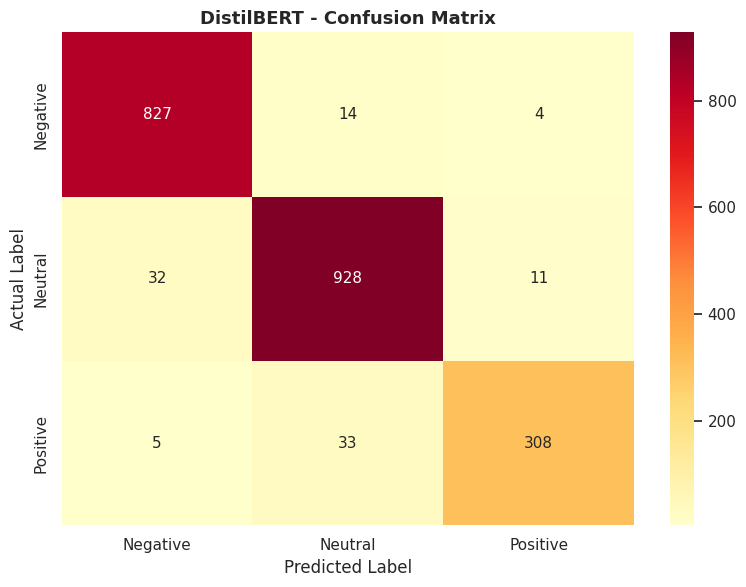

DistilBERT Macro F1: 0.9474 | Weighted F1: 0.9540


In [ ]:
bert_val_metrics = trainer.evaluate(eval_dataset=val_ds)
bert_preds = trainer.predict(test_ds)
y_pred_bert = np.argmax(bert_preds.predictions, axis=1)
bert_accuracy = accuracy_score(bert_test_labels, y_pred_bert)

label_names = ['Negative', 'Neutral', 'Positive']
print(f"DistilBERT Validation Accuracy: {bert_val_metrics.get('eval_accuracy', np.nan):.4f}")
print(f"DistilBERT Test Accuracy: {bert_accuracy:.4f}")
print("\nDistilBERT Classification Report:")
print(classification_report(bert_test_labels, y_pred_bert, target_names=label_names))

bert_cm = confusion_matrix(bert_test_labels, y_pred_bert)
plt.figure(figsize=(8, 6))
sns.heatmap(bert_cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=label_names, yticklabels=label_names)
plt.title('DistilBERT - Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

bert_f1_macro = f1_score(bert_test_labels, y_pred_bert, average='macro')
bert_f1_weighted = f1_score(bert_test_labels, y_pred_bert, average='weighted')
print(f"DistilBERT Macro F1: {bert_f1_macro:.4f} | Weighted F1: {bert_f1_weighted:.4f}")

---
# Segment 10: Opinion Mining
spaCy dependency parsing is used to extract opinion targets and opinion expressions from tweet text.

In [ ]:
import spacy

nlp = spacy.load('en_core_web_sm')
print(f"spaCy version: {spacy.__version__}")
print(f"Pipeline components: {nlp.pipe_names}")

spaCy version: 3.8.14
Pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [ ]:
def extract_svo(text):
    doc     = nlp(str(text))
    triples = []
    for token in doc:
        if token.dep_ == 'ROOT' and token.pos_ == 'VERB':
            subj = [w.text for w in token.lefts
                    if w.dep_ in ('nsubj', 'nsubjpass')]
            obj  = [w.text for w in token.rights
                    if w.dep_ in ('dobj', 'attr', 'pobj')]
            if subj and obj:
                triples.append({
                    'subject': subj[0],
                    'verb':    token.text,
                    'object':  obj[0]
                })
    return triples

print("Testing SVO extraction:")
test_tweets = [
    "The staff was very rude to me",
    "I love the legroom on this flight",
    "United lost my luggage again",
]
for tweet in test_tweets:
    print(f"\n  Tweet:   '{tweet}'")
    print(f"  Triples: {extract_svo(tweet)}")

Testing SVO extraction:

  Tweet:   'The staff was very rude to me'
  Triples: []

  Tweet:   'I love the legroom on this flight'
  Triples: [{'subject': 'I', 'verb': 'love', 'object': 'legroom'}]

  Tweet:   'United lost my luggage again'
  Triples: [{'subject': 'United', 'verb': 'lost', 'object': 'luggage'}]


In [ ]:
# filter noisy opinion targets and expressions
opinion_target_noise = {
    'i', 'you', 'we', 'they', 'he', 'she', 'it', 'that', 'this', 'what', 'who',
    'them', 'him', 'her', 'us', 'me', 'my', 'your', 'our', 'their',
    'flight', 'flights', 'airline', 'airlines', 'plane', 'airport', 'air',
    'thanks', 'thank', 'amp', 'rt', 'dm',
    'customer', 'service', 'help', 'phone', 'email', 'call', 'time',
    'thing', 'people', 'home', 'week', 'year', 'night', 'morning',
    'today', 'tomorrow', 'weather', 'work', 'way'
}

opinion_expr_noise = {
    'last', 'new', 'first', 'other', 'next', 'more', 'same', 'only',
    'many', 'different', 'few', 'several', 'own', 'such', 'able',
    'sure', 'really', 'much'
}


def clean_opinion_word(word):
    word = re.sub(r'[^a-z]', '', str(word).lower())
    return word


def extract_noun_adj_pairs(text):
    doc = nlp(str(text))
    pairs = []
    for token in doc:
        target = clean_opinion_word(token.text)
        if token.pos_ == 'NOUN' and target not in opinion_target_noise and len(target) > 2:
            adjs = []
            for child in token.children:
                adj = clean_opinion_word(child.text)
                if child.pos_ == 'ADJ' and adj not in opinion_expr_noise and len(adj) > 2:
                    adjs.append(adj)
            if adjs:
                pairs.append({'target': target, 'opinion': adjs})
    return pairs

print("Testing noun-adjective pair extraction:")
for tweet in test_tweets:
    print(f"\n  Tweet: '{tweet}'")
    print(f"  Pairs: {extract_noun_adj_pairs(tweet)}")


Testing noun-adjective pair extraction:

  Tweet: 'The staff was very rude to me'
  Pairs: []

  Tweet: 'I love the legroom on this flight'
  Pairs: []

  Tweet: 'United lost my luggage again'
  Pairs: []


In [ ]:
def extract_svo_from_doc(doc):
    triples = []
    for token in doc:
        if token.dep_ == 'ROOT' and token.pos_ == 'VERB':
            subj = [w.text for w in token.lefts
                    if w.dep_ in ('nsubj', 'nsubjpass')]
            obj  = [w.text for w in token.rights
                    if w.dep_ in ('dobj', 'attr', 'pobj')]
            if subj and obj:
                triples.append({
                    'subject': subj[0],
                    'verb':    token.text,
                    'object':  obj[0]
                })
    return triples


def extract_noun_adj_pairs_from_doc(doc):
    pairs = []
    for token in doc:
        target = clean_opinion_word(token.text)
        if token.pos_ == 'NOUN' and target not in opinion_target_noise and len(target) > 2:
            adjs = []
            for child in token.children:
                adj = clean_opinion_word(child.text)
                if child.pos_ == 'ADJ' and adj not in opinion_expr_noise and len(adj) > 2:
                    adjs.append(adj)
            if adjs:
                pairs.append({'target': target, 'opinion': adjs})
    return pairs


df_opinion = df.copy().reset_index(drop=True)
svo_rows = []
pair_rows = []

for doc in nlp.pipe(df_opinion['text'].astype(str).tolist(), batch_size=64):
    svo_rows.append(extract_svo_from_doc(doc))
    pair_rows.append(extract_noun_adj_pairs_from_doc(doc))

df_opinion['svo_triples'] = svo_rows
df_opinion['noun_adj_pairs'] = pair_rows

total_opinion_tweets = len(df_opinion)
tweets_with_svo   = df_opinion['svo_triples'].apply(len).gt(0).sum()
tweets_with_pairs = df_opinion['noun_adj_pairs'].apply(len).gt(0).sum()

print(f"Tweets processed:                {total_opinion_tweets:,}")
print(f"Tweets with SVO triples:        {tweets_with_svo:,} "
      f"({tweets_with_svo/total_opinion_tweets*100:.1f}%)")
print(f"Tweets with noun-adj pairs:     {tweets_with_pairs:,} "
      f"({tweets_with_pairs/total_opinion_tweets*100:.1f}%)")
print("\nOpinion mining preview:")
print(df_opinion[['text', 'svo_triples', 'noun_adj_pairs']].head(5).to_string())

Tweets processed:                14,409
Tweets with SVO triples:        4,769 (33.1%)
Tweets with noun-adj pairs:     3,755 (26.1%)

Opinion mining preview:
                                                                                                                             text                                                                svo_triples                                                                                          noun_adj_pairs
0                                                                                             @VirginAmerica What @dhepburn said.                                                                         []                                                                                                      []
1                                                        @VirginAmerica plus you've added commercials to the experience... tacky.  [{'subject': '@VirginAmerica', 'verb': 'added', 'object': 'commercials'}]                     

Top 20 Most Frequent Opinion Targets:
Opinion Target  Frequency
    experience        131
           day         80
         seats         63
         agent         63
      response         52
          seat         51
          trip         48
           bag         48
           job         47
        issues         45
          crew         41
        person         36
         staff         34
        agents         32
     customers         31
          days         28
        number         28
          line         27
         delay         26
        system         23


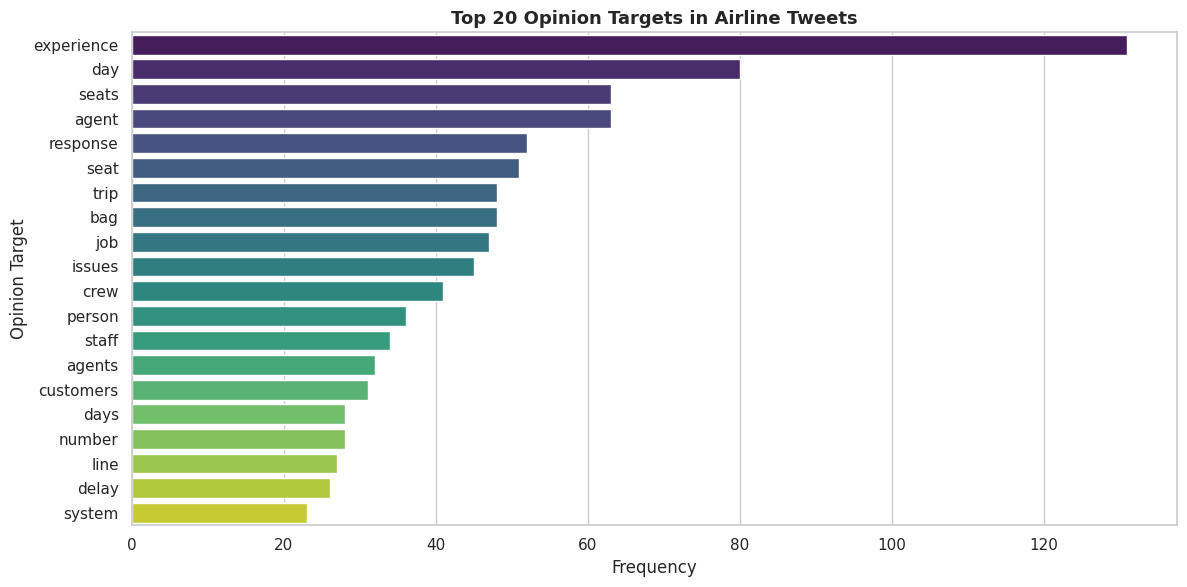

In [ ]:
all_targets = []
for pairs in df_opinion['noun_adj_pairs']:
    for pair in pairs:
        target = clean_opinion_word(pair['target'])
        if target and target not in opinion_target_noise and len(target) > 2:
            all_targets.append(target)

target_df = pd.DataFrame(
    Counter(all_targets).most_common(20), columns=['Opinion Target', 'Frequency'])

print("Top 20 Most Frequent Opinion Targets:")
print(target_df.to_string(index=False))

plt.figure(figsize=(12, 6))
sns.barplot(data=target_df, x='Frequency', y='Opinion Target', palette='viridis')
plt.title('Top 20 Opinion Targets in Airline Tweets',
          fontsize=13, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Opinion Target')
plt.tight_layout()
plt.show()

Top 20 Opinion Expressions:
Opinion Expression  Frequency
            united        247
             great        136
              good        116
           jetblue         81
              free         70
             worst         68
              best         67
        mechanical         60
             extra         58
              long         55
              full         52
               bad         50
              poor         42
              real         41
              open         41
              gate         40
              rude         40
               old         37
               big         37
            online         36


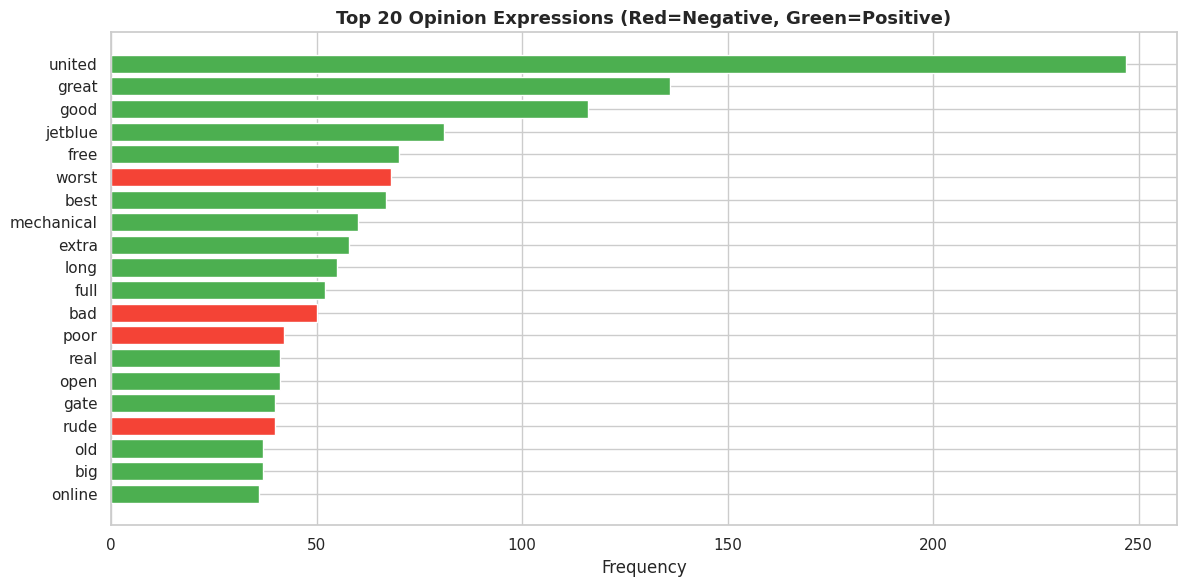

In [ ]:
all_exprs = []
for pairs in df_opinion['noun_adj_pairs']:
    for pair in pairs:
        for adj in pair['opinion']:
            adj = clean_opinion_word(adj)
            if adj and adj not in opinion_expr_noise and len(adj) > 2:
                all_exprs.append(adj)

expr_df = pd.DataFrame(
    Counter(all_exprs).most_common(20), columns=['Opinion Expression', 'Frequency'])

print("Top 20 Opinion Expressions:")
print(expr_df.to_string(index=False))

neg_words = {'bad','worst','terrible','awful','late','delayed',
             'rude','horrible','poor','wrong','lost','cancelled',
             'angry','frustrated','disappointed'}
expr_colors = [
    '#F44336' if w in neg_words else '#4CAF50'
    for w in expr_df['Opinion Expression']
]
plt.figure(figsize=(12, 6))
plt.barh(expr_df['Opinion Expression'][::-1],
         expr_df['Frequency'][::-1],
         color=expr_colors[::-1])
plt.title('Top 20 Opinion Expressions (Red=Negative, Green=Positive)',
          fontsize=13, fontweight='bold')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

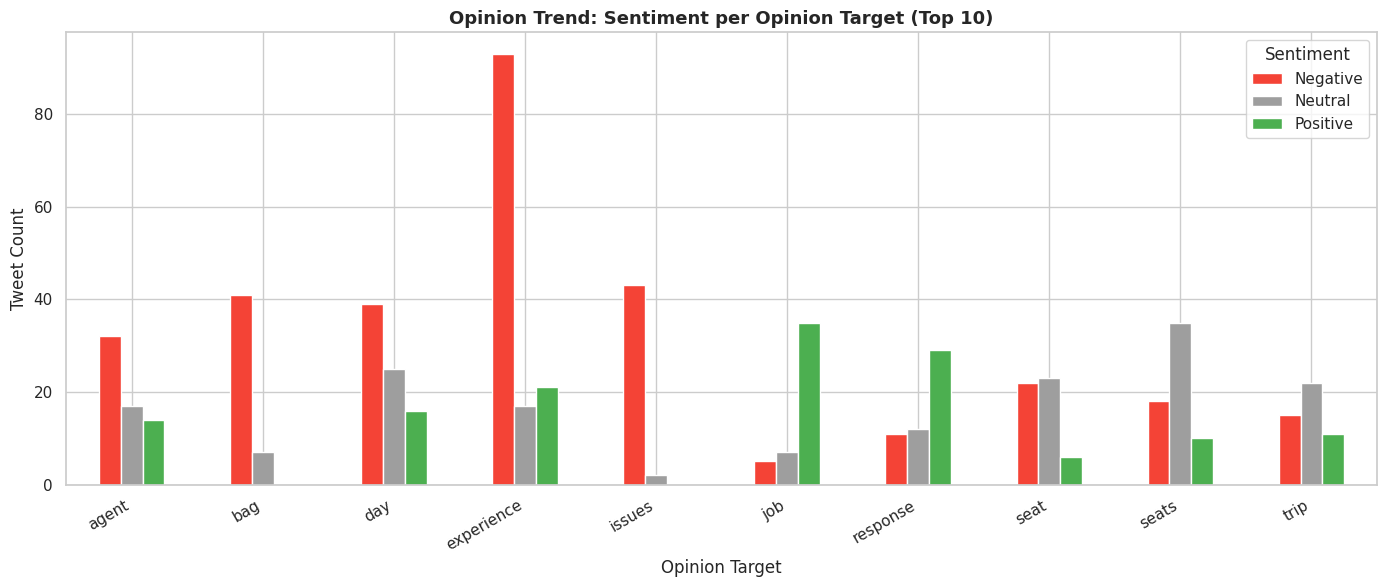

In [ ]:
target_sent_pairs = []
for _, row in df_opinion.iterrows():
    lbl = row['ground_truth_sentiment']
    for pair in row['noun_adj_pairs']:
        target_sent_pairs.append({'Target': pair['target'].lower(), 'Sentiment': lbl})

ts_df = pd.DataFrame(target_sent_pairs)

if len(ts_df) > 0:
    top10 = ts_df['Target'].value_counts().head(10).index.tolist()
    pivot = (ts_df[ts_df['Target'].isin(top10)]
               .groupby(['Target','Sentiment'])
               .size()
               .unstack(fill_value=0))

    pivot.plot(kind='bar', figsize=(14, 6),
               color=['#F44336', '#9E9E9E', '#4CAF50'], edgecolor='white')
    plt.title('Opinion Trend: Sentiment per Opinion Target (Top 10)',
              fontsize=13, fontweight='bold')
    plt.xlabel('Opinion Target')
    plt.ylabel('Tweet Count')
    plt.legend(title='Sentiment')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

---
# Segment 11: Aspect-Based Sentiment Analysis
Aspects are detected using airline service keywords. Sentiment is scored using VADER compound scores.

In [ ]:
aspect_keywords = {
    'Customer Service': ['service','staff','crew','agent','representative',
                         'employee','attendant','team','support','help'],
    'Delays':           ['delay','late','wait','hold','time','hour',
                         'schedule','departure','arrival','missed'],
    'Baggage':          ['luggage','bag','baggage','suitcase','lost',
                         'damage','claim','checked'],
    'Booking':          ['book','booking','reservation','ticket','cancel',
                         'reschedule','refund','purchase','website'],
    'Comfort':          ['seat','legroom','space','comfort','cabin',
                         'class','row','upgrade','clean'],
    'Food':             ['food','meal','drink','snack','water',
                         'eat','coffee','menu','beverage'],
}
print("Aspect categories defined:")
for asp, kws in aspect_keywords.items():
    print(f"  {asp:20s} -> {kws[:4]} ...")

Aspect categories defined:
  Customer Service     -> ['service', 'staff', 'crew', 'agent'] ...
  Delays               -> ['delay', 'late', 'wait', 'hold'] ...
  Baggage              -> ['luggage', 'bag', 'baggage', 'suitcase'] ...
  Booking              -> ['book', 'booking', 'reservation', 'ticket'] ...
  Comfort              -> ['seat', 'legroom', 'space', 'comfort'] ...
  Food                 -> ['food', 'meal', 'drink', 'snack'] ...


In [ ]:
def detect_aspects(text, asp_dict):
    text_lower = str(text).lower()
    detected   = [asp for asp, kws in asp_dict.items()
                  if any(kw in text_lower for kw in kws)]
    return detected if detected else ['General']

df['detected_aspects'] = df['text'].apply(
    lambda t: detect_aspects(t, aspect_keywords))

from itertools import chain
all_asp = list(chain.from_iterable(df['detected_aspects']))
print("Aspect Mention Counts:")
for asp, cnt in sorted(Counter(all_asp).items(), key=lambda x: -x[1]):
    print(f"  {asp:20s}: {cnt:,}")

tweets_with_asp = df[df['detected_aspects'].apply(lambda x: x != ['General'])].shape[0]
print(f"\nTweets with identified aspects: {tweets_with_asp:,} / {len(df):,}")

Aspect Mention Counts:
  General             : 5,435
  Delays              : 3,855
  Customer Service    : 3,102
  Booking             : 2,412
  Food                : 1,549
  Baggage             : 1,340
  Comfort             : 1,168

Tweets with identified aspects: 8,974 / 14,409


In [ ]:
vader_absa = SentimentIntensityAnalyzer()

absa_records = []
for _, row in df.iterrows():
    score = vader_absa.polarity_scores(str(row['text']))['compound']
    sent  = ('Positive' if score >= 0.05
             else 'Negative' if score <= -0.05 else 'Neutral')
    for asp in row['detected_aspects']:
        if asp != 'General':
            absa_records.append({'Aspect': asp, 'Sentiment': sent, 'Score': score})

absa_df = pd.DataFrame(absa_records)
print(f"Total aspect-sentiment records: {len(absa_df):,}")
print("\nAspect-Sentiment Distribution:")
print(absa_df.groupby(['Aspect','Sentiment']).size().unstack(fill_value=0))

Total aspect-sentiment records: 13,426

Aspect-Sentiment Distribution:
Sentiment         Negative  Neutral  Positive
Aspect                                       
Baggage                535      175       630
Booking               1024      307      1081
Comfort                360      194       614
Customer Service      1057      283      1762
Delays                1659      613      1583
Food                   503      171       875


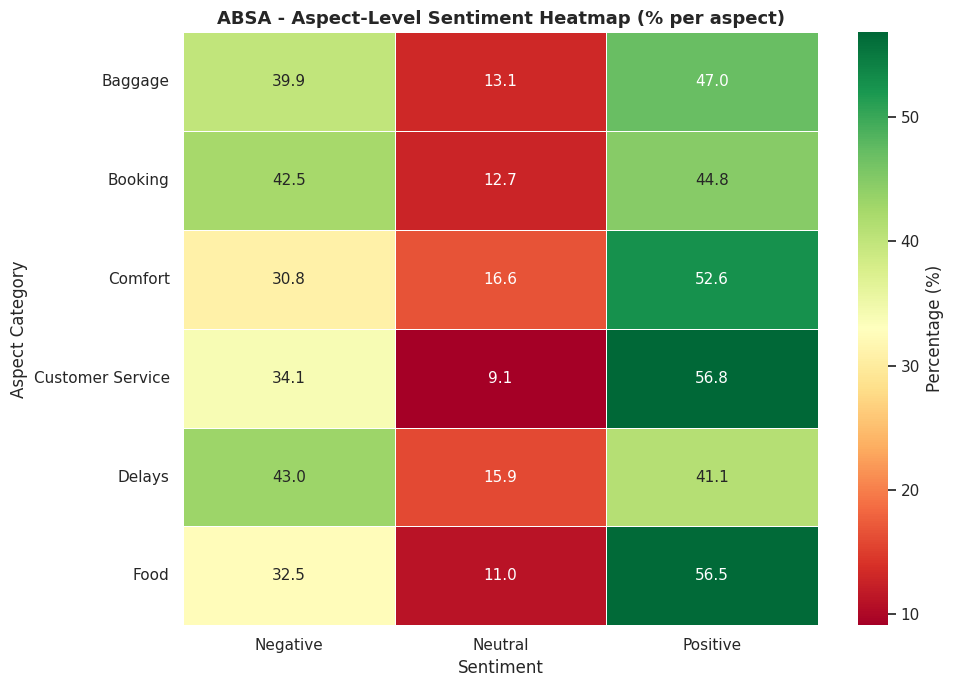

In [ ]:
absa_pivot = absa_df.groupby(['Aspect','Sentiment']).size().unstack(fill_value=0)
for col in ['Positive','Neutral','Negative']:
    if col not in absa_pivot.columns:
        absa_pivot[col] = 0
absa_pivot = absa_pivot[['Negative','Neutral','Positive']]
absa_pct   = absa_pivot.div(absa_pivot.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 7))
sns.heatmap(absa_pct, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Percentage (%)'})
plt.title('ABSA - Aspect-Level Sentiment Heatmap (% per aspect)',
          fontsize=13, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Aspect Category')
plt.tight_layout()
plt.show()

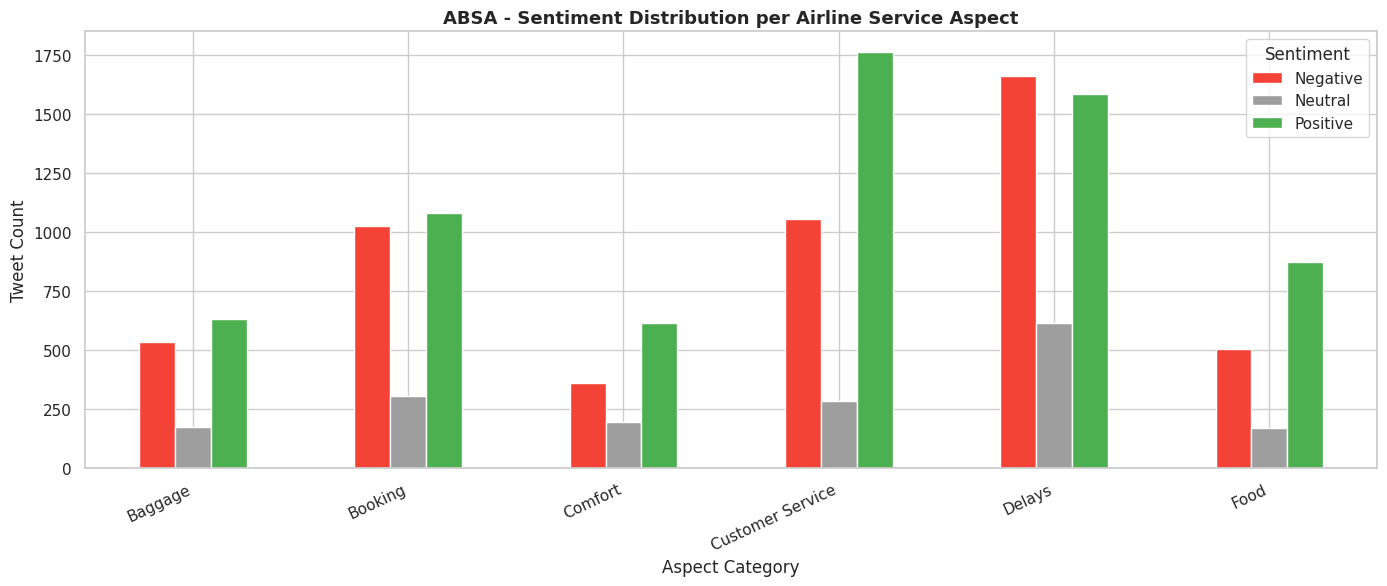

In [ ]:
absa_pivot.plot(kind='bar', figsize=(14, 6),
                color=['#F44336','#9E9E9E','#4CAF50'], edgecolor='white')
plt.title('ABSA - Sentiment Distribution per Airline Service Aspect',
          fontsize=13, fontweight='bold')
plt.xlabel('Aspect Category')
plt.ylabel('Tweet Count')
plt.legend(title='Sentiment')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

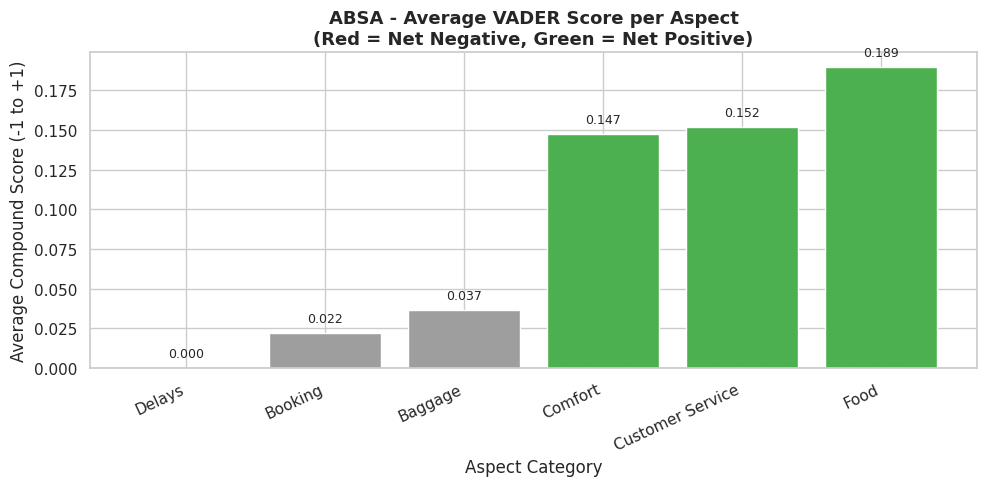


Average VADER score per aspect:
Aspect
Delays              0.0004
Booking             0.0219
Baggage             0.0368
Comfort             0.1474
Customer Service    0.1520
Food                0.1895
Name: Score, dtype: float64

Negative score = passengers are unhappy with this aspect.


In [ ]:
avg_score = absa_df.groupby('Aspect')['Score'].mean().sort_values()

bar_c = ['#F44336' if s < -0.05 else ('#4CAF50' if s > 0.05 else '#9E9E9E')
         for s in avg_score.values]

plt.figure(figsize=(10, 5))
bars = plt.bar(avg_score.index, avg_score.values, color=bar_c, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('ABSA - Average VADER Score per Aspect\n'
          '(Red = Net Negative, Green = Net Positive)',
          fontsize=13, fontweight='bold')
plt.ylabel('Average Compound Score (-1 to +1)')
plt.xlabel('Aspect Category')
plt.xticks(rotation=25, ha='right')
for bar, val in zip(bars, avg_score.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.005 if val >= 0 else -0.015),
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print("\nAverage VADER score per aspect:")
print(avg_score.round(4))
print("\nNegative score = passengers are unhappy with this aspect.")

Tweets processed for noun phrases: 14,409
Total noun phrases extracted:      33,694

Top 20 Noun Phrases (Potential Aspect Targets):
 Noun Phrase  Frequency
        hold        513
       hours        290
        time        219
     minutes        164
   the phone        152
       fleek        149
      people        148
     nothing        137
        help        125
      no one        122
    the gate        121
     weather        111
late flightr        111
     an hour        110
      anyone        110
      united        103
       which         95
        mins         94
  passengers         93
        bags         89


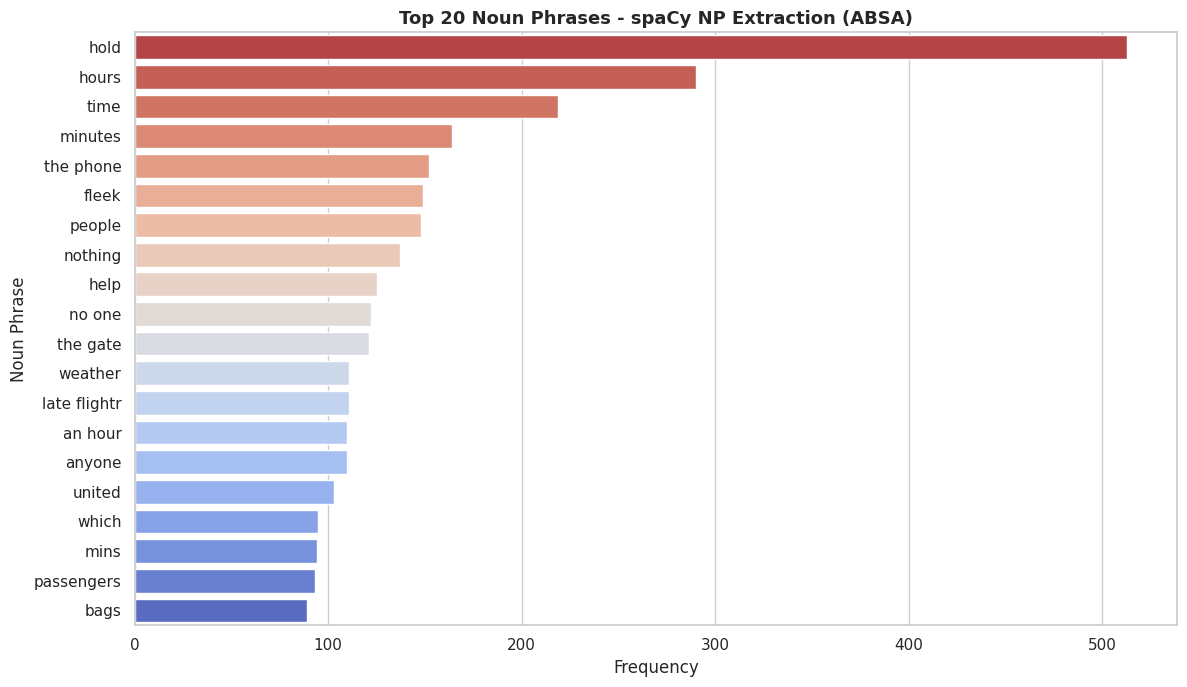

In [ ]:
# clean noun phrases so the chart shows useful aspect targets
noun_phrase_noise = {
    'i', 'you', 'we', 'they', 'he', 'she', 'it', 'that', 'this', 'what',
    'them', 'him', 'her', 'us', 'me', 'my', 'your', 'our', 'their',
    'flight', 'flights', 'a flight', 'my flight', 'the flight',
    'airline', 'airlines', 'plane', 'airport', 'air',
    'thanks', 'thank', 'amp', 'rt', 'dm', 'someone', 'anything', 'thing',
    'you guys', 'customer'
}


def clean_noun_phrase(text):
    phrase = str(text).lower()
    phrase = re.sub(r'@\w+', '', phrase)
    phrase = re.sub(r'[^a-z\s]', ' ', phrase)
    phrase = re.sub(r'\s+', ' ', phrase).strip()
    return phrase


def extract_noun_phrases_from_doc(doc):
    phrases = []
    for chunk in doc.noun_chunks:
        phrase = clean_noun_phrase(chunk.text)
        if len(phrase) < 4:
            continue
        if phrase in noun_phrase_noise:
            continue
        if any(word in noun_phrase_noise for word in phrase.split()) and len(phrase.split()) <= 2:
            continue
        if len(phrase.split()) > 4:
            continue
        phrases.append(phrase)
    return phrases


df_absa_np = df.copy().reset_index(drop=True)
noun_phrase_rows = []
for doc in nlp.pipe(df_absa_np['text'].astype(str).tolist(), batch_size=64):
    noun_phrase_rows.append(extract_noun_phrases_from_doc(doc))

df_absa_np['noun_phrases'] = noun_phrase_rows

all_nps = [np_ for nps in df_absa_np['noun_phrases'] for np_ in nps]
np_df = pd.DataFrame(Counter(all_nps).most_common(20),
                     columns=['Noun Phrase','Frequency'])

print(f"Tweets processed for noun phrases: {len(df_absa_np):,}")
print(f"Total noun phrases extracted:      {len(all_nps):,}")
print("\nTop 20 Noun Phrases (Potential Aspect Targets):")
print(np_df.to_string(index=False))

plt.figure(figsize=(12, 7))
sns.barplot(data=np_df, x='Frequency', y='Noun Phrase', palette='coolwarm_r')
plt.title('Top 20 Noun Phrases - spaCy NP Extraction (ABSA)',
          fontsize=13, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Noun Phrase')
plt.tight_layout()
plt.show()

In [ ]:
absa_summary = (
    absa_df.groupby('Aspect').agg(
        Total_Mentions=('Sentiment', 'count'),
        Positive_Count=('Sentiment', lambda x: (x == 'Positive').sum()),
        Neutral_Count=('Sentiment', lambda x: (x == 'Neutral').sum()),
        Negative_Count=('Sentiment', lambda x: (x == 'Negative').sum()),
        Avg_Score=('Score', 'mean'),
    ).round(4).reset_index()
)
absa_summary['Positive_%'] = (
    absa_summary['Positive_Count'] / absa_summary['Total_Mentions'] * 100).round(1)
absa_summary['Negative_%'] = (
    absa_summary['Negative_Count'] / absa_summary['Total_Mentions'] * 100).round(1)
absa_summary = absa_summary.sort_values('Avg_Score').reset_index(drop=True)

print("ABSA Summary Table:")
print(absa_summary.to_string(index=False))
print("\nKey Insight: Aspects with lower average scores show higher service dissatisfaction.")

ABSA Summary Table:
          Aspect  Total_Mentions  Positive_Count  Neutral_Count  Negative_Count  Avg_Score  Positive_%  Negative_%
          Delays            3855            1583            613            1659     0.0004        41.1        43.0
         Booking            2412            1081            307            1024     0.0219        44.8        42.5
         Baggage            1340             630            175             535     0.0368        47.0        39.9
         Comfort            1168             614            194             360     0.1474        52.6        30.8
Customer Service            3102            1762            283            1057     0.1520        56.8        34.1
            Food            1549             875            171             503     0.1895        56.5        32.5

Key Insight: Aspects with lower average scores show higher service dissatisfaction.


---
# Segment 12: Final Benchmarking and Generalisation Check

This segment selects the best lexicon baseline, compares trained models and summarises the final results. Lexicon scores are agreement scores. Trained model scores are test accuracy scores.

BEST LEXICON BASELINE
Best lexicon baseline: AFINN
Agreement score: 0.5949

TRAINED MODEL COMPARISON


,Model,Approach,Score_Type,Features,CV_Mean_Acc,Main_Score,Macro_F1,Weighted_F1
0,Logistic Regression,Traditional ML,Test Accuracy,TF-IDF + SMOTE,0.9209,0.9264,0.9166,0.9265
1,Linear SVM,Traditional ML,Test Accuracy,TF-IDF + SMOTE,0.9239,0.9323,0.9252,0.9325
2,BiLSTM,Deep Learning,Test Accuracy,Token sequences + BiLSTM,NaN,0.9524,0.9475,0.9523
3,DistilBERT,Transformer,Test Accuracy,Contextual embeddings,NaN,0.9542,0.9474,0.9540


Best trained model: DistilBERT
Best trained model test accuracy: 0.9542

FINAL BENCHMARKING SUMMARY


,Model,Approach,Score_Type,Features,CV_Mean_Acc,Main_Score,Macro_F1,Weighted_F1
0,AFINN,Lexicon,Agreement with rule-based ground truth,Lexicon score,NaN,0.5949,0.5930,0.5990
1,VADER,Lexicon,Agreement with rule-based ground truth,Lexicon compound,NaN,0.5530,0.5497,0.5572
2,TextBlob,Lexicon,Agreement with rule-based ground truth,Lexicon polarity,NaN,0.5324,0.5292,0.5325
3,Logistic Regression,Traditional ML,Test Accuracy,TF-IDF + SMOTE,0.9209,0.9264,0.9166,0.9265
4,Linear SVM,Traditional ML,Test Accuracy,TF-IDF + SMOTE,0.9239,0.9323,0.9252,0.9325
5,BiLSTM,Deep Learning,Test Accuracy,Token sequences + BiLSTM,NaN,0.9524,0.9475,0.9523
6,DistilBERT,Transformer,Test Accuracy,Contextual embeddings,NaN,0.9542,0.9474,0.9540


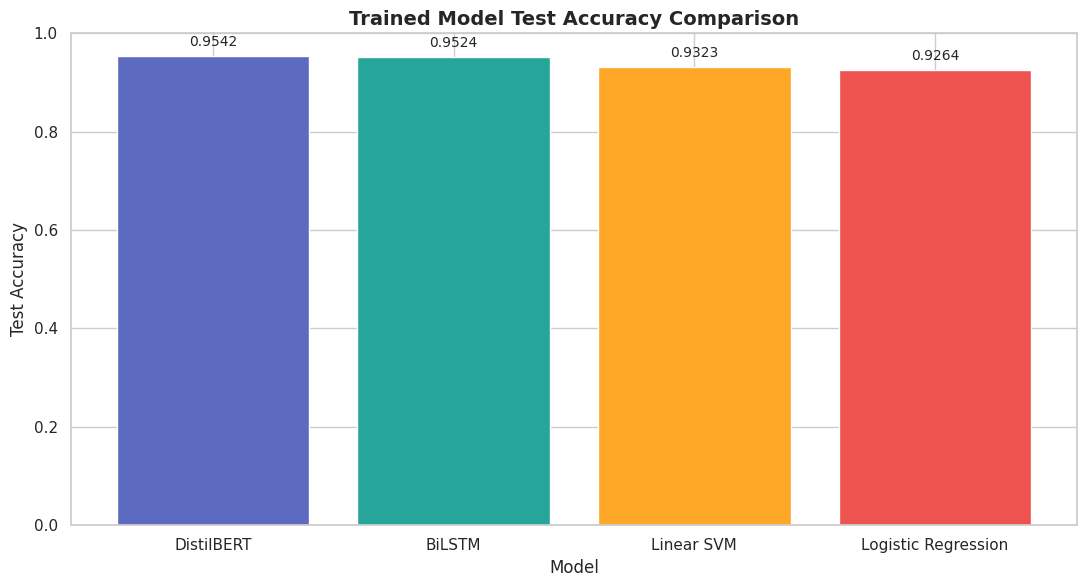

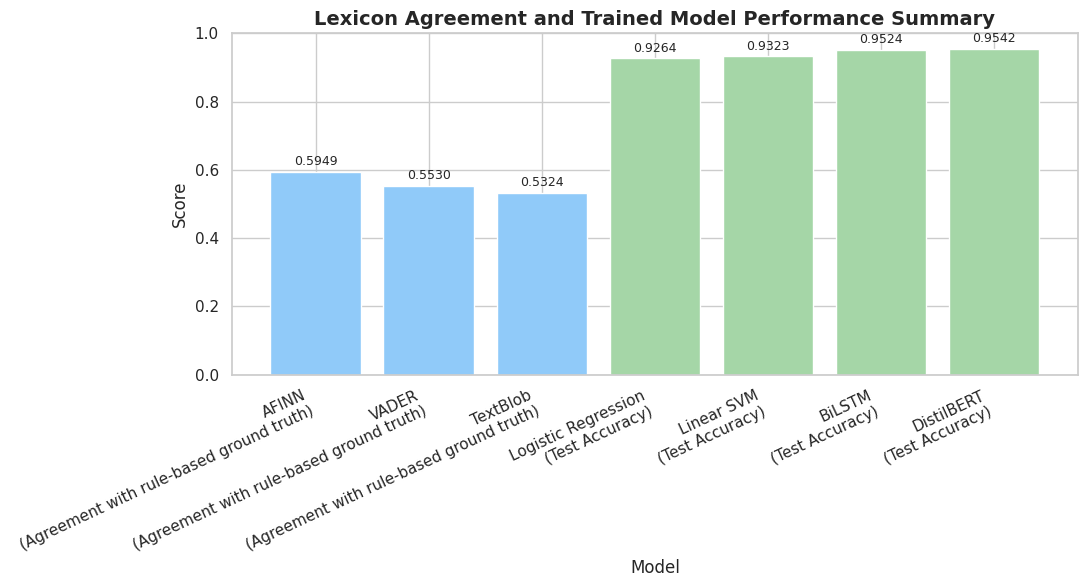

Lexicon scores are agreement scores with the rule-based ground truth label.
Trained model scores are test accuracy scores.


In [ ]:
lex_lookup = lexicon_eval.set_index('Model')

trained_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Linear SVM',
        'BiLSTM',
        'DistilBERT'
    ],
    'Approach': [
        'Traditional ML',
        'Traditional ML',
        'Deep Learning',
        'Transformer'
    ],
    'Score_Type': [
        'Test Accuracy',
        'Test Accuracy',
        'Test Accuracy',
        'Test Accuracy'
    ],
    'Features': [
        'TF-IDF + SMOTE',
        'TF-IDF + SMOTE',
        'Token sequences + BiLSTM',
        'Contextual embeddings'
    ],
    'CV_Mean_Acc': [
        round(lr_cv_scores.mean(), 4),
        round(svm_cv_scores.mean(), 4),
        None,
        None
    ],
    'Main_Score': [
        round(lr_accuracy, 4),
        round(svm_accuracy, 4),
        round(bilstm_accuracy, 4),
        round(bert_accuracy, 4)
    ],
    'Macro_F1': [
        round(lr_f1_macro, 4),
        round(svm_f1_macro, 4),
        round(bilstm_f1_macro, 4),
        round(bert_f1_macro, 4)
    ],
    'Weighted_F1': [
        round(lr_f1_weighted, 4),
        round(svm_f1_weighted, 4),
        round(bilstm_f1_weighted, 4),
        round(bert_f1_weighted, 4)
    ]
})

best_trained_model = trained_results.sort_values(by='Main_Score', ascending=False).iloc[0]

final_results = pd.concat([
    lexicon_eval.assign(
        Features=lexicon_eval['Model'].map({
            'TextBlob': 'Lexicon polarity',
            'VADER': 'Lexicon compound',
            'AFINN': 'Lexicon score'
        }),
        CV_Mean_Acc=None,
        Main_Score=lexicon_eval['Agreement'],
        Macro_F1=lexicon_eval['F1_Macro'],
        Weighted_F1=lexicon_eval['F1_Weighted']
    )[
        ['Model', 'Approach', 'Score_Type', 'Features', 'CV_Mean_Acc',
         'Main_Score', 'Macro_F1', 'Weighted_F1']
    ],
    trained_results
], ignore_index=True)

print("=" * 70)
print("BEST LEXICON BASELINE")
print("=" * 70)
print(f"Best lexicon baseline: {best_lexicon_name}")
print(f"Agreement score: {best_lexicon_score:.4f}")

print("\n" + "=" * 70)
print("TRAINED MODEL COMPARISON")
print("=" * 70)
display(trained_results.round(4))

print(f"Best trained model: {best_trained_model['Model']}")
print(f"Best trained model test accuracy: {best_trained_model['Main_Score']:.4f}")

print("\n" + "=" * 70)
print("FINAL BENCHMARKING SUMMARY")
print("=" * 70)
display(final_results.round(4))

plt.figure(figsize=(11, 6))
trained_plot = trained_results.sort_values(by='Main_Score', ascending=False)

bars = plt.bar(
    trained_plot['Model'],
    trained_plot['Main_Score'],
    color=['#5C6BC0', '#26A69A', '#FFA726', '#EF5350']
)

plt.title('Trained Model Test Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{bar.get_height():.4f}",
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))
final_plot = final_results.copy()
final_plot['Display_Label'] = final_plot['Model'] + '\n(' + final_plot['Score_Type'] + ')'

bars = plt.bar(
    final_plot['Display_Label'],
    final_plot['Main_Score'],
    color=[
        '#90CAF9' if score_type == 'Agreement with rule-based ground truth' else '#A5D6A7'
        for score_type in final_plot['Score_Type']
    ]
)

plt.title('Lexicon Agreement and Trained Model Performance Summary', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=25, ha='right')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{bar.get_height():.4f}",
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

print("Lexicon scores are agreement scores with the rule-based ground truth label.")
print("Trained model scores are test accuracy scores.")

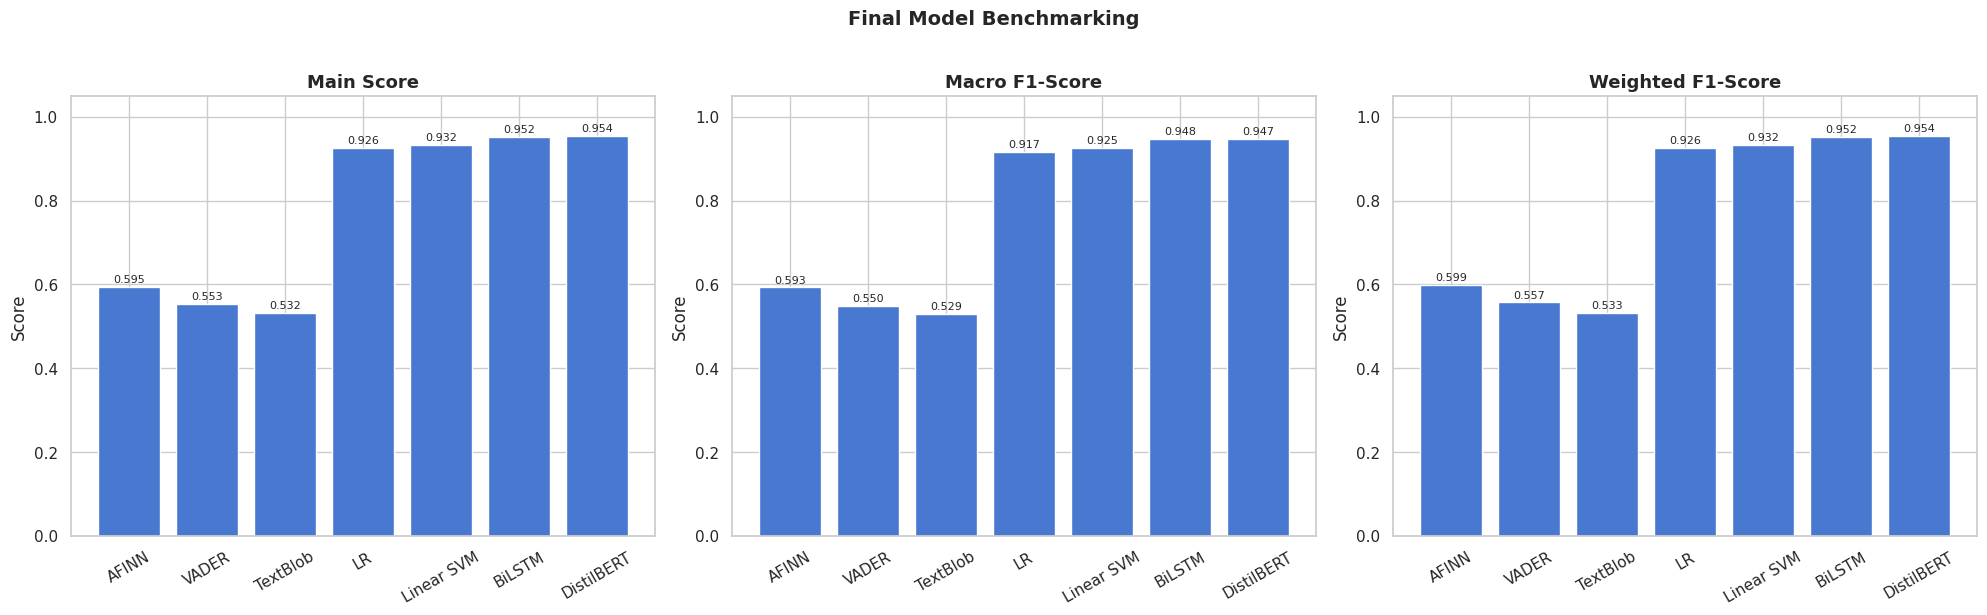

In [ ]:
model_names = final_results['Model'].replace({
    'Logistic Regression': 'LR',
}).tolist()
scores = final_results['Main_Score'].astype(float).tolist()
macro_f1s = final_results['Macro_F1'].astype(float).tolist()
wt_f1s = final_results['Weighted_F1'].astype(float).tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, values, title in [
    (axes[0], scores, 'Main Score'),
    (axes[1], macro_f1s, 'Macro F1-Score'),
    (axes[2], wt_f1s, 'Weighted F1-Score'),
]:
    bars = ax.bar(model_names, values, edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim(0.0, 1.05)
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=8)

plt.suptitle('Final Model Benchmarking', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

GENERALISATION CHECK
Logistic Regression:
  5-Fold CV Mean Accuracy : 0.9209 +/- 0.0033
  Test Set Accuracy       : 0.9264
  Gap                     : 0.0056
  Assessment              : Low gap

Linear SVM:
  5-Fold CV Mean Accuracy : 0.9239 +/- 0.0028
  Test Set Accuracy       : 0.9323
  Gap                     : 0.0084
  Assessment              : Low gap

BiLSTM:
  Training Accuracy       : 0.9772
  Validation Accuracy     : 0.9639
  Test Set Accuracy       : 0.9524
  Training-Val Gap        : 0.0133
  Val-Test Gap            : 0.0115
  Assessment              : Low gap

DistilBERT:
  Validation Accuracy     : 0.9500
  Test Set Accuracy       : 0.9542
  Gap                     : 0.0042
  Assessment              : Low gap


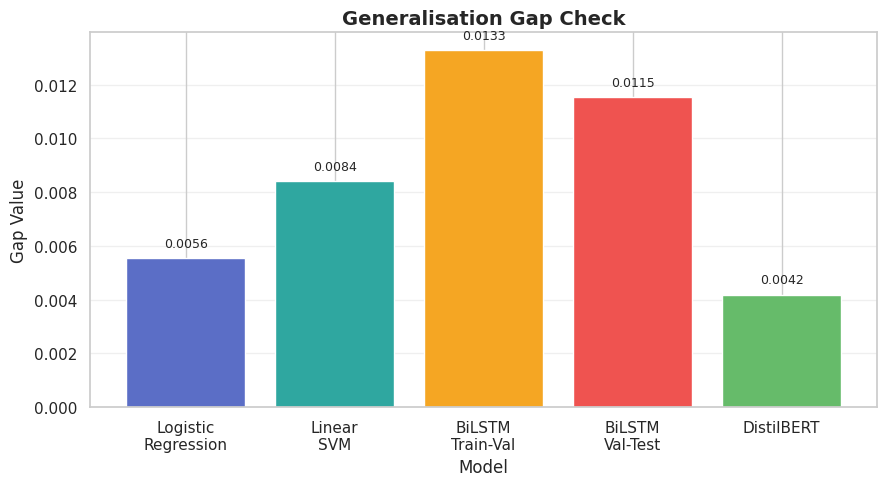

In [ ]:
lr_gap = abs(lr_accuracy - lr_cv_scores.mean())
svm_gap = abs(svm_accuracy - svm_cv_scores.mean())

bilstm_train_acc = bilstm_train_accuracy
bilstm_val_acc = bilstm_val_accuracy
bilstm_test_gap = bilstm_val_test_gap

bert_val_acc = bert_val_metrics.get('eval_accuracy', np.nan)
bert_gap = abs(bert_accuracy - bert_val_acc) if not np.isnan(bert_val_acc) else np.nan

print("=" * 60)
print("GENERALISATION CHECK")
print("=" * 60)

print("Logistic Regression:")
print(f"  5-Fold CV Mean Accuracy : {lr_cv_scores.mean():.4f} +/- {lr_cv_scores.std():.4f}")
print(f"  Test Set Accuracy       : {lr_accuracy:.4f}")
print(f"  Gap                     : {lr_gap:.4f}")
print(f"  Assessment              : {'Low gap' if lr_gap < 0.03 else 'Acceptable gap' if lr_gap < 0.06 else 'Noticeable gap'}")

print()
print("Linear SVM:")
print(f"  5-Fold CV Mean Accuracy : {svm_cv_scores.mean():.4f} +/- {svm_cv_scores.std():.4f}")
print(f"  Test Set Accuracy       : {svm_accuracy:.4f}")
print(f"  Gap                     : {svm_gap:.4f}")
print(f"  Assessment              : {'Low gap' if svm_gap < 0.03 else 'Acceptable gap' if svm_gap < 0.06 else 'Noticeable gap'}")

print()
print("BiLSTM:")
print(f"  Training Accuracy       : {bilstm_train_acc:.4f}")
print(f"  Validation Accuracy     : {bilstm_val_acc:.4f}")
print(f"  Test Set Accuracy       : {bilstm_accuracy:.4f}")
print(f"  Training-Val Gap        : {bilstm_overfit_gap:.4f}")
print(f"  Val-Test Gap            : {bilstm_test_gap:.4f}")
print(f"  Assessment              : {bilstm_generalisation_status}")

print()
print("DistilBERT:")
print(f"  Validation Accuracy     : {bert_val_acc:.4f}")
print(f"  Test Set Accuracy       : {bert_accuracy:.4f}")
print(f"  Gap                     : {bert_gap:.4f}")
print(f"  Assessment              : {'Low gap' if bert_gap < 0.03 else 'Acceptable gap' if bert_gap < 0.06 else 'Noticeable gap'}")


# Generalisation gap chart

gap_labels = [
    "Logistic\nRegression",
    "Linear\nSVM",
    "BiLSTM\nTrain-Val",
    "BiLSTM\nVal-Test",
    "DistilBERT"
]

gap_values = [
    lr_gap,
    svm_gap,
    bilstm_overfit_gap,
    bilstm_test_gap,
    bert_gap
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    gap_labels,
    gap_values,
    color=["#5B6EC6", "#2FA7A0", "#F5A623", "#EF5350", "#66BB6A"]
)

plt.title("Generalisation Gap Check", fontsize=14, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("Gap Value")
plt.grid(axis="y", linestyle="-", alpha=0.3)

for bar, value in zip(bars, gap_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0003,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [ ]:
summary_df = pd.DataFrame({
    'Model': ['TextBlob / VADER / AFINN', 'Logistic Regression', 'Linear SVM',
              'BiLSTM', 'DistilBERT'],
    'Type': ['Lexicon', 'Traditional ML', 'Traditional ML', 'Deep Learning', 'Transformer'],
    'Strength': [
        'Works without labelled training data and gives interpretable sentiment scores',
        'Fast and easy to interpret with TF-IDF features',
        'Strong margin-based classifier for sparse text features',
        'Captures sequence patterns in short tweet text',
        'Uses contextual language understanding for tweet classification',
    ],
    'Limitation': [
        'Agreement is measured against rule-based ground truth labels',
        'Bag-of-words representation does not model word order',
        'Does not capture word meaning directly',
        'Needs suitable regularisation for stable generalisation',
        'Needs more computation and is slower to fine-tune',
    ],
})
print("Model strengths and limitations:")
display(summary_df)

Model strengths and limitations:


,Model,Type,Strength,Limitation
0,TextBlob / VADER / AFINN,Lexicon,Works without labelled training data and gives...,Agreement is measured against rule-based groun...
1,Logistic Regression,Traditional ML,Fast and easy to interpret with TF-IDF features,Bag-of-words representation does not model wor...
2,Linear SVM,Traditional ML,Strong margin-based classifier for sparse text...,Does not capture word meaning directly
3,BiLSTM,Deep Learning,Captures sequence patterns in short tweet text,Needs suitable regularisation for stable gener...
4,DistilBERT,Transformer,Uses contextual language understanding for twe...,Needs more computation and is slower to fine-tune


---
# Segment 13: Save Models and Outputs

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import joblib

saved_models_folder = "/content/drive/MyDrive/Social media computing/saved_models"
os.makedirs(saved_models_folder, exist_ok=True)

print("Saved models folder:")
print(saved_models_folder)

# Save traditional ML models
joblib.dump(best_lr, os.path.join(saved_models_folder, "logistic_regression_pipeline.pkl"))
joblib.dump(best_svm, os.path.join(saved_models_folder, "svm_pipeline.pkl"))

# Save TF-IDF vectorizer
joblib.dump(best_lr.named_steps["tfidf"], os.path.join(saved_models_folder, "tfidf_vectorizer.pkl"))

# Save label encoder
joblib.dump(le_dl, os.path.join(saved_models_folder, "label_encoder.pkl"))

# Save BiLSTM model and tokenizer
bilstm_model.save(os.path.join(saved_models_folder, "bilstm_model.keras"))

with open(os.path.join(saved_models_folder, "keras_tokenizer.json"), "w", encoding="utf-8") as f:
    f.write(keras_tok.to_json())

# Save Word2Vec model
w2v_model.save(os.path.join(saved_models_folder, "word2vec_model.bin"))

# Save DistilBERT model and tokenizer
bert_clf.save_pretrained(os.path.join(saved_models_folder, "distilbert_model"))
bert_tok.save_pretrained(os.path.join(saved_models_folder, "distilbert_tokenizer"))

# Save CSV outputs
df.to_csv(os.path.join(saved_models_folder, "processed_tweets.csv"), index=False)

df[
    ["text", "clean_text", "ground_truth_sentiment", "ground_truth_rule_source"]
].to_csv(
    os.path.join(saved_models_folder, "ground_truth_sentiment_labels.csv"),
    index=False
)

lexicon_eval.to_csv(os.path.join(saved_models_folder, "lexicon_agreement.csv"), index=False)
absa_summary.to_csv(os.path.join(saved_models_folder, "absa_summary.csv"), index=False)
final_results.to_csv(os.path.join(saved_models_folder, "model_comparison.csv"), index=False)
summary_df.to_csv(os.path.join(saved_models_folder, "model_strengths_limitations.csv"), index=False)

print("\nFiles saved inside saved_models folder:")
for item in os.listdir(saved_models_folder):
    print("-", item)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved models folder:
/content/drive/MyDrive/Social media computing/saved_models


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Files saved inside saved_models folder:
- logistic_regression_pipeline.pkl
- svm_pipeline.pkl
- tfidf_vectorizer.pkl
- label_encoder.pkl
- bilstm_model.keras
- keras_tokenizer.json
- word2vec_model.bin
- distilbert_model
- distilbert_tokenizer
- processed_tweets.csv
- ground_truth_sentiment_labels.csv
- lexicon_agreement.csv
- absa_summary.csv
- model_comparison.csv
- model_strengths_limitations.csv


#Insights

- The final notebook shows that trained models perform better than the lexicon-based baseline models. Among the lexicon methods, AFINN gives the highest agreement with the rule-based ground truth sentiment label. This shows that AFINN is the strongest lexicon baseline in this project. However, the agreement score is still much lower than the trained model accuracy, which means that lexicon models alone are not enough to fully understand airline tweet sentiment.

- For the traditional machine learning models, Linear SVM performs slightly better than Logistic Regression. Logistic Regression achieves a test accuracy of 0.9264, while Linear SVM achieves 0.9323. This shows that TF-IDF features are effective for short tweet classification. Linear SVM performs well because it can handle high-dimensional sparse text features. However, TF-IDF still has a limitation because it does not fully capture word order or contextual meaning.

- The deep learning and transformer models give the strongest results. BiLSTM achieves a test accuracy of 0.9524, while DistilBERT achieves the highest test accuracy of 0.9542. This shows that sequence learning and contextual language understanding are useful for airline tweet sentiment classification. DistilBERT performs slightly better because it can understand the meaning of words based on their surrounding context.

- The generalisation gap check shows that the trained models do not have strong evidence of overfitting. Logistic Regression, Linear SVM, BiLSTM and DistilBERT all have low gap values. This means the models perform consistently between training, validation, cross-validation and test data. The BiLSTM model has a higher training-validation gap than the other models, but the validation-test gap is still low, so the final model remains stable.

- The opinion mining results show that passengers often discuss targets such as hold, hours, time, minutes, phone, people, help, gate and bags. These terms show that many airline tweets are related to waiting time, customer support, gate experience and baggage handling. This is useful because opinion mining explains the common topics behind the sentiment labels.

- The ABSA results provide more detailed service-level insights. Delays have the highest number of aspect mentions and also show a high negative percentage. Booking also has a high negative percentage, which suggests that passengers often face issues related to reservations, tickets or booking changes. Baggage also appears as an important complaint area. On the other hand, food, customer service and comfort have higher positive percentages compared to delays and booking. This shows that passenger dissatisfaction is mainly linked to operational issues such as delays and booking problems rather than all service areas equally.

- Overall, the project shows that sentiment analysis becomes more useful when it is combined with opinion mining and ABSA. Model accuracy explains how well the system classifies tweets, while ABSA explains which service aspects are responsible for the sentiment. Therefore, the final pipeline is useful for both technical model comparison and practical airline service insight generation.